In [17]:
import os, heapq, itertools, warnings
from datetime import date

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker

import stable_baselines3, sb3_contrib

In [18]:
# ── PDE:  u_t + c u_x = alpha u_xx   on x in [0, 1],  u(0,t) = u(1,t) = 0 ──
alpha = 0.1          # diffusion coefficient
c     = 1.0          # advection speed

# ── Grid: every point the map can use sits on this grid ──
nx = 100
T  = 0.5
dx = 1.0 / (nx - 1)
dt_cfl = min(0.9 * dx / c, 0.45 * dx**2 / alpha)     # advective and diffusive limits
nt = max(int(np.ceil(T / dt_cfl)) + 1, 10)
dt = T / (nt - 1)

# ── Exact solution ──
# u = exp(b x - alpha b^2 t) v  with  b = c / (2 alpha)  removes the advection term;
# v solves the heat equation, so it is a sine series.
_xq = np.linspace(0.0, 1.0, 80001)
_b  = c / (2 * alpha)
u0  = lambda x: np.sin(np.pi * x) + 0.5 * np.sin(2 * np.pi * x)
_v0 = u0(_xq) * np.exp(-_b * _xq)
_n  = np.arange(1, 801)
_bn = np.array([2 * np.trapezoid(_v0 * np.sin(k * np.pi * _xq), _xq) for k in _n])

def u_true(x, t):
    """Exact u at positions x (scalar or array) and one time t. Always returns an array."""
    x = np.atleast_1d(np.asarray(x, dtype=float))
    v = (np.sin(np.pi * np.outer(x, _n)) * (_bn * np.exp(-alpha * (_n * np.pi)**2 * t))).sum(axis=1)
    return np.exp(_b * x - alpha * _b**2 * t) * v

print(f"nx = {nx}, nt = {nt}, dx = {dx:.5f}, dt = {dt:.3e}")
print(f"check at t = 0: max |u_true - u0| = {np.abs(u_true(np.arange(nx) * dx, 0.0) - u0(np.arange(nx) * dx)).max():.1e}")

nx = 100, nt = 1090, dx = 0.01010, dt = 4.591e-04
check at t = 0: max |u_true - u0| = 4.5e-07


In [19]:
# ── FD reference: the tight central stencil at every point ──
r, nu = alpha * dt / dx**2, c * dt / dx
W_FD = np.array([r + nu / 2, 1 - 2 * r, r - nu / 2])      # weights for (x-dx, x, x+dx)
_fd_cache = {}
def fd_reference(ix, it):
    """FD at z* = (ix, it): (u_fd, E_FD, C_FD) = value, error, number of computed points."""
    if (ix, it) in _fd_cache:
        return _fd_cache[(ix, it)]
    u = u_true(np.arange(nx) * dx, 0.0)                    # level 0: initial condition
    for _ in range(it):
        u[1:-1] = W_FD[0] * u[:-2] + W_FD[1] * u[1:-1] + W_FD[2] * u[2:]
        u[0] = u[-1] = 0.0                                   # boundaries
    u_fd = u[ix]
    E_FD = abs(u_fd - u_true(ix * dx, it * dt)[0])
    C_FD = sum(min(nx - 2, ix + j) - max(1, ix - j) + 1 for j in range(it))
    _fd_cache[(ix, it)] = (u_fd, E_FD, C_FD)
    return _fd_cache[(ix, it)]

In [20]:
COND_MAX = 1e4
W_MAX    = 2     # cap on ||w||_1, the per-level error-amplification factor (thesis Thm 2.7)

def solve_weights(dxs, dts, w_max=W_MAX):
    """Min-norm weights for the 3 PDE-substituted Taylor rows (constant, u_x, u_xx).
    None if rank-deficient, ill-conditioned (cond > COND_MAX), or ||w||_1 > w_max."""
    h = max(np.abs(dxs).max(), np.sqrt(alpha * np.abs(dts).max()))
    A = np.array([np.ones_like(dxs),
                  (dxs - c * dts) / h,
                  (0.5 * (dxs - c * dts)**2 + alpha * dts) / h**2])
    if np.linalg.matrix_rank(A) < 3 or np.linalg.cond(A) > COND_MAX:
        return None
    w = np.linalg.pinv(A) @ np.array([1.0, 0.0, 0.0])
    return w if np.abs(w).sum() <= w_max else None

w3 = solve_weights(np.array([-1, 0, 1]) * dx, np.array([-1, -1, -1]) * dt)
print("3 points one level down:", np.round(w3, 5))
print("Lax-Wendroff weights:   ", np.round([r + nu/2 + nu**2/2, 1 - 2*r - nu**2, r - nu/2 + nu**2/2], 5))

3 points one level down: [0.47376 0.09793 0.42831]
Lax-Wendroff weights:    [0.47376 0.09793 0.42831]


In [21]:
# ── Downward window: neighbours only from earlier time levels ──
R_X, K_T = 2, 2                     # |dix| <= 2 cells,  dit in {-1, -2}
WINDOW  = [(dix, dit) for dit in range(-1, -K_T - 1, -1) for dix in range(-R_X, R_X + 1)]
N_CELLS = len(WINDOW)
N_NB    = 5                         # neighbours per stencil

U0 = u_true(np.arange(nx) * dx, 0.0)      # initial condition on the grid

def is_known(ix, it):
    """Initial condition or wall: the value is given, not computed."""
    return it == 0 or ix == 0 or ix == nx - 1

def known_value(ix, it):
    return U0[ix] if it == 0 else 0.0

def place(ix, it, a):
    """Grid point of window cell a seen from (ix, it). Past a wall or below t = 0 -> moved onto it."""
    dix, dit = WINDOW[a]
    return (min(max(ix + dix, 0), nx - 1), max(it + dit, 0))

def distinct_cells(ix, it):
    """One window cell per distinct grid point (cells moved onto the same wall/IC point count once)."""
    out, used = [], set()
    for a in range(N_CELLS):
        q = place(ix, it, a)
        if q not in used:
            used.add(q)
            out.append(a)
    return out

def n_picks(ix, it):
    """Stencil size at (ix, it): 5, or fewer if the window has fewer distinct points."""
    return min(N_NB, len(distinct_cells(ix, it)))

In [22]:
# ── Stencil from picked cells, and its geometry score ──
L_SOL = 1 / (2 * np.pi)            # solution length scale: shortest mode of the IC, sin(2 pi x)

_w_cache = {}
def stencil(ix, it, cells):
    """(neighbour points, weights) for the picked cells, weights computed at the PLACED positions.
    None if the stencil is inadmissible."""
    nbs  = [place(ix, it, a) for a in sorted(cells)]
    offs = tuple((q[0] - ix, q[1] - it) for q in nbs)
    if offs not in _w_cache:
        _w_cache[offs] = solve_weights(np.array([o[0] for o in offs]) * dx, np.array([o[1] for o in offs]) * dt)
    w = _w_cache[offs]
    return None if w is None else (nbs, w)

def score(ix, it, nbs, w):
    """Estimated local error of the stencil, from geometry only:
    what is left of the Taylor series after the 3 rows cancel T0, T1, T2."""
    DX = np.array([q[0] - ix for q in nbs]) * dx
    DT = np.array([q[1] - it for q in nbs]) * dt
    xi = DX - c * DT
    m3 = w @ (xi**3 + 6 * alpha * DT * xi)                                  # leftover on T3
    m4 = w @ (xi**4 + 12 * alpha * DT * xi**2 + 12 * (alpha * DT)**2)       # leftover on T4
    return abs(m3) / (6 * L_SOL**3) + abs(m4) / (24 * L_SOL**4)

# check at p = (50, 20): score vs the true local error (u_true used ONLY for this check)
p = (50, 20)
for name, cells in [("row 1 level down ", [0, 1, 2, 3, 4]), ("row 2 levels down", [5, 6, 7, 8, 9])]:
    nbs, w = stencil(*p, cells)
    delta = u_true(p[0] * dx, p[1] * dt)[0] - sum(wq * u_true(q[0] * dx, q[1] * dt)[0] for q, wq in zip(nbs, w))
    print(f"{name}: weights {np.round(w, 3)}  score {score(*p, nbs, w):.1e}  true local error {abs(delta):.1e}")

print("4 IC points at (1, 1):", stencil(1, 1, distinct_cells(1, 1)))

row 1 level down : weights [0.052 0.283 0.357 0.274 0.034]  score 1.7e-06  true local error 6.8e-07
row 2 levels down: weights [0.191 0.223 0.227 0.205 0.154]  score 1.0e-05  true local error 3.6e-06
4 IC points at (1, 1): ([(0, 0), (1, 0), (2, 0), (3, 0)], array([0.40051653, 0.31766529, 0.20857438, 0.0732438 ]))


In [23]:
# ── The map, built backward from z* ──
def start_map(z_star):
    """Empty map for the query z*: only z* is pending, with influence 1."""
    return {"z_star":  z_star,
            "pending": [(-z_star[1], z_star[0])],   # heap: always pop the LATEST t first
            "beta":    {z_star: 1.0},               # influence of each computed point on z*
            "stencil": {}}                          # point -> (neighbour points, weights)

def next_point(m):
    """The point that gets its stencil next (latest t), without removing it."""
    neg_it, ix = m["pending"][0]
    return ix, -neg_it

def expand(m, cells):
    """Give the next point the stencil of the picked cells and pass its influence down.
    Returns (point, new points created, its term |beta_p| * s_p)."""
    neg_it, ix = heapq.heappop(m["pending"])
    p = (ix, -neg_it)
    nbs, w = stencil(*p, cells)
    m["stencil"][p] = (nbs, w)
    n_new = 0
    for q, wq in zip(nbs, w):
        if is_known(*q):
            continue                                 # IC or wall: exact, a leaf
        if q not in m["beta"]:
            m["beta"][q] = 0.0
            heapq.heappush(m["pending"], (-q[1], q[0]))
            n_new += 1
        m["beta"][q] += m["beta"][p] * wq
    return p, n_new, abs(m["beta"][p]) * score(*p, nbs, w)

# check: build a whole map where every point uses "5 in a row, one level down"
m = start_map((50, 6))
B = 0.0
while m["pending"]:
    p, n_new, term = expand(m, [0, 1, 2, 3, 4])
    B += term
print("points computed:", len(m["stencil"]), "| sum of |beta| * score:", f"{B:.2e}")
for it in range(6, 0, -1):
    print(f"  level {it}: {sum(1 for q in m['beta'] if q[1] == it):2d} points, sum of beta = {sum(b for q, b in m['beta'].items() if q[1] == it):.3f}")

points computed: 66 | sum of |beta| * score: 1.02e-05
  level 6:  1 points, sum of beta = 1.000
  level 5:  5 points, sum of beta = 1.000
  level 4:  9 points, sum of beta = 1.000
  level 3: 13 points, sum of beta = 1.000
  level 2: 17 points, sum of beta = 1.000
  level 1: 21 points, sum of beta = 1.000


In [24]:
# ── Forward pass: compute the values bottom-up, from the IC and walls to z* ──
def evaluate(m):
    """u_hat at every computed point of a finished map (no pending points left)."""
    u_hat = {}
    value = lambda q: known_value(*q) if is_known(*q) else u_hat[q]
    for p in sorted(m["stencil"], key=lambda p: p[1]):          # increasing t: neighbours are ready
        nbs, w = m["stencil"][p]
        u_hat[p] = sum(wq * value(q) for q, wq in zip(nbs, w))
    return u_hat

# check on the map from Cell 7 (u_true used ONLY for checking)
z = m["z_star"]
u_hat = evaluate(m)
err = u_true(z[0] * dx, z[1] * dt)[0] - u_hat[z]
print(f"error at z* = {z}: {abs(err):.2e}   (FD: {fd_reference(*z)[1]:.2e} with {fd_reference(*z)[2]} points)")

# the error splits exactly into one term per point: e(z*) = sum_p beta_p * delta_p
U = lambda q: u_true(q[0] * dx, q[1] * dt)[0]
delta = {p: U(p) - sum(wq * U(q) for q, wq in zip(nbs, w)) for p, (nbs, w) in m["stencil"].items()}
print(f"true error {err:+.6e}   sum of beta*delta {sum(m['beta'][p] * delta[p] for p in delta):+.6e}")

error at z* = (50, 6): 4.17e-06   (FD: 1.54e-05 with 36 points)
true error +4.170761e-06   sum of beta*delta +4.170761e-06


In [25]:
# ── Admissible stencils at a point, and the mask for the next pick ──
_sets_cache = {}
def admissible_sets(ix, it):
    """Every choice of n_picks(ix, it) distinct cells whose stencil is admissible."""
    key = tuple((q[0] - ix, q[1] - it) for q in (place(ix, it, a) for a in range(N_CELLS)))  # the local situation
    if key not in _sets_cache:
        cells = distinct_cells(ix, it)
        _sets_cache[key] = [s for s in itertools.combinations(cells, n_picks(ix, it))
                            if stencil(ix, it, s) is not None]
    return _sets_cache[key]

def pick_mask(ix, it, picks):
    """Cell a may be picked next if some admissible stencil contains the picks so far plus a."""
    mask = np.zeros(N_CELLS, dtype=bool)
    for s in admissible_sets(ix, it):
        if set(picks) <= set(s):
            mask[[a for a in s if a not in picks]] = True
    return mask

for p in [(50, 10), (50, 1), (1, 1), (1, 5)]:
    print(f"at {p}: {len(admissible_sets(*p)):3d} admissible stencils of size {n_picks(*p)} | "
          f"first pick allowed on {pick_mask(*p, []).sum()} cells")
print("at (50, 10) after picking cells 0 and 9:", np.flatnonzero(pick_mask(50, 10, [0, 9])))

at (50, 10): 240 admissible stencils of size 5 | first pick allowed on 10 cells
at (50, 1):   1 admissible stencils of size 5 | first pick allowed on 5 cells
at (1, 1):   1 admissible stencils of size 4 | first pick allowed on 4 cells
at (1, 5):  50 admissible stencils of size 5 | first pick allowed on 8 cells
at (50, 10) after picking cells 0 and 9: [1 2 3 4 5 6 7 8]


In [26]:
# ── Reference map and greedy baseline ──
def build_map(z_star, choose):
    """Build a whole map; choose(m, p) returns the cells for point p. Returns (map, sum |beta| s, points)."""
    m, B = start_map(z_star), 0.0
    while m["pending"]:
        p = next_point(m)
        _, _, term = expand(m, choose(m, p))
        B += term
    return m, B, len(m["stencil"])

def n_new_points(m, p, cells):
    """How many new computed points this stencil would create."""
    return sum(1 for q in set(place(*p, a) for a in cells) if not is_known(*q) and q not in m["beta"])

def s_of(p, cells):
    return score(*p, *stencil(*p, cells))

# Reference: every point takes its lowest-score admissible stencil (ignores influence and cost)
choose_ref = lambda m, p: min(admissible_sets(*p), key=lambda s: s_of(p, s))

# Greedy: every point takes the stencil with the lowest immediate reward cost
def make_greedy(B_ref, N_ref, lam):
    return lambda m, p: min(admissible_sets(*p),
                            key=lambda s: abs(m["beta"][p]) * s_of(p, s) / B_ref + lam * n_new_points(m, p, s) / N_ref)

def true_error(m):
    z = m["z_star"]
    return abs(evaluate(m)[z] - u_true(z[0] * dx, z[1] * dt)[0])    # u_true ONLY for reporting

In [27]:
# ── The environment: one step = one pick; a reward every time a stencil is completed ──
_ref_cache = {}
def reference(z_star):
    """(B_ref, N_ref) for this query: score sum and point count of the reference map."""
    if z_star not in _ref_cache:
        _, B_ref, N_ref = build_map(z_star, choose_ref)
        _ref_cache[z_star] = (B_ref, N_ref)
    return _ref_cache[z_star]

N_OBS = 3 * N_CELLS + 5

class LocalRewardEnv(gym.Env):
    def __init__(self, queries, lam=1.0, cap=3.0):
        super().__init__()
        self.queries, self.lam, self.cap = queries, lam, cap
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(N_OBS,), dtype=np.float32)
        self.action_space = spaces.Discrete(N_CELLS)          # one action = one window cell

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.z_star = self.queries[self.np_random.integers(len(self.queries))]
        self.B_ref, self.N_ref = reference(self.z_star)
        self.m, self.picks, self.B = start_map(self.z_star), [], 0.0
        self._play_forced()                                   # only matters if z* is one level above the IC
        return self._obs(), {}

    def _complete(self, cells):
        """Expand the next point with these cells; return its reward."""
        p, n_new, term = expand(self.m, cells)
        self.B += term
        return -term / self.B_ref - self.lam * n_new / self.N_ref

    def _play_forced(self):
        """Points with exactly one admissible stencil (e.g. one level above the IC) need no decision."""
        r = 0.0
        while self.m["pending"] and len(admissible_sets(*next_point(self.m))) == 1:
            r += self._complete(admissible_sets(*next_point(self.m))[0])
        return r

    def _obs(self):
        if not self.m["pending"]:
            return np.zeros(N_OBS, np.float32)
        p = next_point(self.m)
        picked, exists, known = np.zeros(N_CELLS), np.zeros(N_CELLS), np.zeros(N_CELLS)
        picked[self.picks] = 1
        for a in range(N_CELLS):
            q = place(*p, a)
            known[a]  = is_known(*q)
            exists[a] = q in self.m["beta"]
        glob = [np.log10(abs(self.m["beta"][p]) + 1e-12),     # influence of this point on z*
                p[1],                                        # levels above the IC
                p[0] - self.z_star[0],                       # offset to z* in x
                len(self.picks),                             # pick number
                len(self.m["stencil"]) / self.N_ref]         # points used so far
        return np.concatenate([picked, exists, known, glob]).astype(np.float32)

    def step(self, a):
        self.picks.append(int(a))
        p = next_point(self.m)
        if len(self.picks) < n_picks(*p):                     # still choosing this point's stencil
            return self._obs(), 0.0, False, False, {}
        r = self._complete(self.picks)
        self.picks = []
        r += self._play_forced()
        N = len(self.m["stencil"]) + len(self.m["pending"])
        if self.m["pending"] and N <= self.cap * self.N_ref:  # map not finished
            return self._obs(), r, False, False, {}
        # finished, or over the point cap: each unexpanded point costs its worst admissible stencil
        for neg_it, ix in self.m["pending"]:
            q = (ix, -neg_it)
            r -= abs(self.m["beta"][q]) * max(s_of(q, s) for s in admissible_sets(*q)) / self.B_ref
        info = {"finished": not self.m["pending"],
                "n_points": len(self.m["stencil"]),
                "score_ratio": self.B / self.B_ref,
                "points_ratio": len(self.m["stencil"]) / self.N_ref,
                "error": true_error(self.m) if not self.m["pending"] else np.nan}   # u_true ONLY for logging
        return np.zeros(N_OBS, np.float32), r, True, False, info

    def action_masks(self):
        return pick_mask(*next_point(self.m), self.picks)

# check: one episode with random (masked) picks
env = LocalRewardEnv(queries=[(50, 10)])
obs, _ = env.reset(seed=0)
rng = np.random.default_rng(0)
total, steps, done = 0.0, 0, False
while not done:
    a = rng.choice(np.flatnonzero(env.action_masks()))
    obs, r, done, _, info = env.step(a)
    total += r; steps += 1
print(f"obs size {N_OBS} | {steps} picks | {info['n_points']} points | error {info['error']:.2e} "
      f"| score {info['score_ratio']:.1f}x reference | points {info['points_ratio']:.2f}x reference")
print(f"sum of rewards {total:.4f}   check: -score_ratio - lam*(points - 1)/N_ref = "
      f"{-info['score_ratio'] - env.lam * (info['n_points'] - 1) / env.N_ref:.4f}")

obs size 35 | 570 picks | 141 points | error 9.02e-06 | score 34.3x reference | points 1.26x reference
sum of rewards -35.5174   check: -score_ratio - lam*(points - 1)/N_ref = -35.5174


In [28]:
# ── Restore: definitions from Cells 12, 14, 17, 20, 21, 25 without re-running any training ──
import time
from matplotlib.colors import LogNorm

class EpisodeLog(BaseCallback):
    """Keeps the info of every finished episode."""
    def __init__(self):
        super().__init__()
        self.episodes = []
    def _on_step(self):
        for info, done in zip(self.locals["infos"], self.locals["dones"]):
            if done:
                self.episodes.append(info)
        return True

class ProgressLog(EpisodeLog):
    """EpisodeLog that also prints a status line every `every` steps."""
    def __init__(self, every=100_000):
        super().__init__()
        self.every, self.next_print, self.t0 = every, every, time.time()
    def _on_step(self):
        super()._on_step()
        if self.num_timesteps >= self.next_print:
            recent = self.episodes[-20:]
            if recent:
                print(f"   {self.num_timesteps / 1e6:4.1f}M steps | {len(self.episodes):4d} episodes | "
                      f"last 20: {np.mean([x['n_points'] for x in recent]):5.0f} pts, score {np.mean([x['score_ratio'] for x in recent]):5.2f}x "
                      f"| {time.time() - self.t0:4.0f} s")
            self.next_print += self.every
        return True

Z_TRAIN, LAM        = (50, 10), 1.0
Z_HARD,  LAM_HARD   = (50, 20), 8.0
N_ENVS              = 12

def terms(m):
    """Each computed point's share of the score sum, relative to the reference."""
    B_ref, _ = reference(m["z_star"])
    return {p: abs(m["beta"][p]) * score(*p, nbs, w) / B_ref for p, (nbs, w) in m["stencil"].items()}

def exact_bound(m):
    """sum over points of |beta_p * delta_p|: the true error with no cancellation allowed (u_true, checking only)."""
    U = lambda q: u_true(q[0] * dx, q[1] * dt)[0]
    return sum(abs(m["beta"][p] * (U(p) - sum(wq * U(q) for q, wq in zip(nbs, w)))) for p, (nbs, w) in m["stencil"].items())

choose_min = lambda m, p: min(admissible_sets(*p), key=lambda s: (n_new_points(m, p, s), s_of(p, s)))

# returns recorded so far at z* = (50, 20), lam = 8 (Cells 20, 23, 25, 27)
results         = {s: {"return": r} for s, r in {0: -8.29, 1: -11.59, 2: -15.04, 3: -14.39, 4: -13.49, 5: -14.36}.items()}
results_pending = {s: {"return": r} for s, r in {1: -13.52, 2: -8.23, 3: -14.05}.items()}
print("restored")

restored


In [12]:
# ── Sanity training run: one query, compared against greedy ──
import time

class EpisodeLog(BaseCallback):
    """Keeps the info of every finished episode."""
    def __init__(self):
        super().__init__()
        self.episodes = []
    def _on_step(self):
        for info, done in zip(self.locals["infos"], self.locals["dones"]):
            if done:
                self.episodes.append(info)
        return True

Z_TRAIN = (50, 10)
LAM     = 1.0
TOTAL   = 400_000

env   = Monitor(LocalRewardEnv(queries=[Z_TRAIN], lam=LAM))
model = MaskablePPO("MlpPolicy", env, n_steps=2048, batch_size=256, gamma=1.0, seed=0, verbose=0)
log   = EpisodeLog()
t0 = time.time()
model.learn(total_timesteps=TOTAL, callback=log)
model.save(f"local_reward_{Z_TRAIN[0]}_{Z_TRAIN[1]}_{date.today()}")
print(f"{TOTAL} steps in {time.time() - t0:.0f} s, {len(log.episodes)} episodes")

# training curve, in 8 chunks
eps, n = log.episodes, max(1, len(log.episodes) // 8)
for k in range(0, len(eps), n):
    chunk = eps[k:k + n]
    print(f"episodes {k:5d}-{k + len(chunk) - 1:5d}: error {np.median([e['error'] for e in chunk]):.2e}  "
          f"points {np.mean([e['n_points'] for e in chunk]):6.1f}  score {np.mean([e['score_ratio'] for e in chunk]):5.2f}x ref")

# trained policy, deterministic, vs the baselines of Cell 10
e = LocalRewardEnv(queries=[Z_TRAIN], lam=LAM)
o, _ = e.reset(seed=0); d = False
while not d:
    a, _ = model.predict(o, action_masks=e.action_masks(), deterministic=True)
    o, r, d, _, info = e.step(a)
B_ref, N_ref = reference(Z_TRAIN)
m_g, B_g, N_g = build_map(Z_TRAIN, make_greedy(B_ref, N_ref, LAM))
print(f"\nz* = {Z_TRAIN}")
print(f"   FD        : error {fd_reference(*Z_TRAIN)[1]:.2e}, {fd_reference(*Z_TRAIN)[2]:4d} points")
print(f"   reference : error {true_error(build_map(Z_TRAIN, choose_ref)[0]):.2e}, {N_ref:4d} points, score 1.00x")
print(f"   greedy    : error {true_error(m_g):.2e}, {N_g:4d} points, score {B_g / B_ref:.2f}x")
print(f"   PPO       : error {info['error']:.2e}, {info['n_points']:4d} points, score {info['score_ratio']:.2f}x")

KeyboardInterrupt: 

In [ ]:
# ── Same run, with an entropy bonus so the policy keeps exploring ──
ENT_COEF = 0.01
TOTAL    = 1_000_000

env   = Monitor(LocalRewardEnv(queries=[Z_TRAIN], lam=LAM))
model = MaskablePPO("MlpPolicy", env, n_steps=2048, batch_size=256, gamma=1.0, ent_coef=ENT_COEF, seed=0, verbose=0)
log   = EpisodeLog()
t0 = time.time()
model.learn(total_timesteps=TOTAL, callback=log)
model.save(f"local_reward_{Z_TRAIN[0]}_{Z_TRAIN[1]}_ent{ENT_COEF}_{date.today()}")
print(f"{TOTAL} steps in {time.time() - t0:.0f} s, {len(log.episodes)} episodes")

ret = lambda score, n_pts, N_ref: -score - LAM * (n_pts - 1) / N_ref      # the episode return
eps, n = log.episodes, max(1, len(log.episodes) // 8)
for k in range(0, len(eps), n):
    chunk = eps[k:k + n]
    print(f"episodes {k:5d}-{k + len(chunk) - 1:5d}: error {np.median([e['error'] for e in chunk]):.2e}  "
          f"points {np.mean([e['n_points'] for e in chunk]):6.1f}  score {np.mean([e['score_ratio'] for e in chunk]):5.2f}x ref")

e = LocalRewardEnv(queries=[Z_TRAIN], lam=LAM)
o, _ = e.reset(seed=0); d = False
while not d:
    a, _ = model.predict(o, action_masks=e.action_masks(), deterministic=True)
    o, r, d, _, info = e.step(a)
B_ref, N_ref = reference(Z_TRAIN)
m_g, B_g, N_g = build_map(Z_TRAIN, make_greedy(B_ref, N_ref, LAM))
print(f"\nz* = {Z_TRAIN}                                   return (higher is better)")
print(f"   reference : error {true_error(build_map(Z_TRAIN, choose_ref)[0]):.2e}, {N_ref:4d} points, score 1.00x   {ret(1.0, N_ref, N_ref):.2f}")
print(f"   greedy    : error {true_error(m_g):.2e}, {N_g:4d} points, score {B_g / B_ref:.2f}x   {ret(B_g / B_ref, N_g, N_ref):.2f}")
print(f"   PPO       : error {info['error']:.2e}, {info['n_points']:4d} points, score {info['score_ratio']:.2f}x   {ret(info['score_ratio'], info['n_points'], N_ref):.2f}")

1000000 steps in 612 s, 2453 episodes
episodes     0-  305: error 3.49e-06  points  107.2  score  8.60x ref
episodes   306-  611: error 1.67e-06  points  100.2  score  2.61x ref
episodes   612-  917: error 1.66e-06  points  100.2  score  2.59x ref
episodes   918- 1223: error 1.65e-06  points  100.0  score  2.59x ref
episodes  1224- 1529: error 1.66e-06  points  100.1  score  2.59x ref
episodes  1530- 1835: error 1.63e-06  points   99.9  score  2.61x ref
episodes  1836- 2141: error 1.58e-06  points  100.0  score  2.60x ref
episodes  2142- 2447: error 1.49e-06  points  100.1  score  2.59x ref
episodes  2448- 2452: error 1.40e-06  points  100.4  score  2.57x ref

z* = (50, 10)                                   return (higher is better)
   reference : error 2.01e-06,  112 points, score 1.00x   -1.99
   greedy    : error 1.21e-06,  105 points, score 1.26x   -2.18
   PPO       : error 1.41e-06,  100 points, score 2.57x   -3.45


In [16]:
# ── Does PPO's map equal FD's cone, and which stencils does it use? ──
from collections import Counter
fd_pts = {(ix, it) for it in range(1, Z_TRAIN[1] + 1)
          for ix in range(Z_TRAIN[0] - (Z_TRAIN[1] - it), Z_TRAIN[0] + (Z_TRAIN[1] - it) + 1)}
print("PPO points == FD cone points:", set(e.m["stencil"]) == fd_pts, f"({len(e.m['stencil'])} vs {len(fd_pts)})")

pat = Counter(tuple(sorted((q[0] - p[0], q[1] - p[1]) for q in nbs)) for p, (nbs, w) in e.m["stencil"].items() if p[1] > 2)
for k, v in pat.most_common(4):
    p0 = next(p for p, (nbs, w) in e.m["stencil"].items() if tuple(sorted((q[0] - p[0], q[1] - p[1]) for q in nbs)) == k)
    print(f"{v:3d} points use offsets {k}  weights {np.round(e.m['stencil'][p0][1], 3)}")
print("FD (FTCS) weights on (-1,-1), (0,-1), (1,-1):", np.round(W_FD, 3))

NameError: name 'e' is not defined

In [ ]:
# ── Score in the state: for each cell, the best stencil score still reachable if it is picked next ──
_scored_cache = {}
def scored_sets(ix, it):
    """For every admissible stencil at (ix, it): which cells it uses (bool matrix) and log10 of its
    score relative to the best one here. Cached per local situation."""
    key = tuple((q[0] - ix, q[1] - it) for q in (place(ix, it, a) for a in range(N_CELLS)))
    if key not in _scored_cache:
        sets = admissible_sets(ix, it)
        uses = np.zeros((len(sets), N_CELLS), dtype=bool)
        for k, s in enumerate(sets):
            uses[k, list(s)] = True
        logs = np.log10([s_of((ix, it), s) for s in sets])
        _scored_cache[key] = (uses, logs - logs.min())
    return _scored_cache[key]

def reachable_score(ix, it, picks):
    """Per cell: log10(best score reachable with picks + that cell / best score at this point).
    0 = the best stencil is still reachable through this cell. Cells that can't be picked get the cap 3."""
    uses, rel = scored_sets(ix, it)
    ok = uses[:, picks].all(axis=1) if picks else np.ones(len(rel), dtype=bool)   # stencils still reachable
    out = np.where(uses[ok], rel[ok, None], 3.0).min(axis=0) if ok.any() else np.full(N_CELLS, 3.0)
    out[picks] = 3.0                                                               # already picked
    return np.minimum(out, 3.0)

class ScoreStateEnv(LocalRewardEnv):
    """LocalRewardEnv plus one number per window cell: how good a stencil can still be built through it."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(N_OBS + N_CELLS,), dtype=np.float32)

    def _obs(self):
        if not self.m["pending"]:
            return np.zeros(N_OBS + N_CELLS, np.float32)
        extra = reachable_score(*next_point(self.m), self.picks)
        return np.concatenate([super()._obs(), extra]).astype(np.float32)

# check at (50, 10): before any pick, and after picking cell 0
print("before any pick:  ", np.round(reachable_score(50, 10, []), 2))
print("after picking 0:  ", np.round(reachable_score(50, 10, [0]), 2))
e16 = ScoreStateEnv(queries=[Z_TRAIN]); o, _ = e16.reset(seed=0)
print("obs size:", o.shape[0])

before any pick:   [0.06 0.   0.16 0.06 0.   0.   0.06 0.   0.   0.06]
after picking 0:   [3.   0.2  0.16 0.06 0.16 0.38 0.06 0.06 0.16 0.06]
obs size: 45


In [15]:
# ── Training with the score in the state, 12 environments in parallel ──
N_ENVS = 12
TOTAL  = 1_000_000

def make_env(queries, lam, seed):
    def _init():
        env = Monitor(ScoreStateEnv(queries=queries, lam=lam))
        env.reset(seed=seed)
        return env
    return _init

vec   = SubprocVecEnv([make_env([Z_TRAIN], LAM, i) for i in range(N_ENVS)])
model = MaskablePPO("MlpPolicy", vec, n_steps=256, batch_size=256, gamma=1.0, seed=0, verbose=1)  # 256 x 12 = 3072 steps per update
log   = EpisodeLog()
t0 = time.time()
model.learn(total_timesteps=TOTAL, callback=log)
vec.close()
model.save(f"local_reward_scorestate_{Z_TRAIN[0]}_{Z_TRAIN[1]}_{date.today()}")
print(f"{TOTAL} steps in {time.time() - t0:.0f} s, {len(log.episodes)} episodes")

ret = lambda score, n_pts, N_ref: -score - LAM * (n_pts - 1) / N_ref      # the episode return
eps, n = log.episodes, max(1, len(log.episodes) // 8)
for k in range(0, len(eps), n):
    chunk = eps[k:k + n]
    print(f"episodes {k:5d}-{k + len(chunk) - 1:5d}: error {np.median([x['error'] for x in chunk]):.2e}  "
          f"points {np.mean([x['n_points'] for x in chunk]):6.1f}  score {np.mean([x['score_ratio'] for x in chunk]):5.2f}x ref")

e = ScoreStateEnv(queries=[Z_TRAIN], lam=LAM)          # named e so Cell 14 plots this map
o, _ = e.reset(seed=0); d = False
while not d:
    a, _ = model.predict(o, action_masks=e.action_masks(), deterministic=True)
    o, r, d, _, info = e.step(a)
B_ref, N_ref = reference(Z_TRAIN)
m_g, B_g, N_g = build_map(Z_TRAIN, make_greedy(B_ref, N_ref, LAM))
print(f"\nz* = {Z_TRAIN}                                   return (higher is better)")
print(f"   reference : error {true_error(build_map(Z_TRAIN, choose_ref)[0]):.2e}, {N_ref:4d} points, score 1.00x   {ret(1.0, N_ref, N_ref):.2f}")
print(f"   greedy    : error {true_error(m_g):.2e}, {N_g:4d} points, score {B_g / B_ref:.2f}x   {ret(B_g / B_ref, N_g, N_ref):.2f}")
print(f"   PPO       : error {info['error']:.2e}, {info['n_points']:4d} points, score {info['score_ratio']:.2f}x   {ret(info['score_ratio'], info['n_points'], N_ref):.2f}")

EOFError: 

In [30]:
# ── Warm start: teach the policy to copy the reference map, then let PPO improve it ──
import torch as th

def demonstrations(queries, choose_set, lam):
    """(obs, action, mask) for every pick made by a set-choosing policy, played through the env."""
    O, A, M = [], [], []
    env = ScoreStateEnv(queries=queries, lam=lam)
    for z in queries:
        env.queries = [z]
        o, _ = env.reset(seed=0); d = False
        while not d:
            p = next_point(env.m)
            for a in sorted(choose_set(env.m, p)):
                O.append(o); A.append(a); M.append(env.action_masks())
                o, r, d, _, info = env.step(a)
                if d: break
    return np.array(O), np.array(A), np.array(M)

def clone(model, O, A, M, epochs=300, lr=1e-3):
    """Supervised: maximise the log-probability of the demonstrated picks under the mask."""
    pol = model.policy
    opt = th.optim.Adam(pol.parameters(), lr=lr)
    o, a, m = (th.as_tensor(x, device=pol.device) for x in (O, A, M))
    for ep in range(epochs):
        dist = pol.get_distribution(o, action_masks=m)
        loss = -dist.log_prob(a).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    with th.no_grad():
        acc = (pol.get_distribution(o, action_masks=m).distribution.probs.argmax(1) == a).float().mean().item()
    return loss.item(), acc

def evaluate_policy(model, z, lam):
    e = ScoreStateEnv(queries=[z], lam=lam); o, _ = e.reset(seed=0); d = False; tot = 0.0
    while not d:
        a, _ = model.predict(o, action_masks=e.action_masks(), deterministic=True)
        o, r, d, _, info = e.step(a); tot += r
    return tot, info, e

O, A, M = demonstrations([Z_TRAIN], choose_ref, LAM)
model = MaskablePPO("MlpPolicy", Monitor(ScoreStateEnv(queries=[Z_TRAIN], lam=LAM)),
                    n_steps=2048, batch_size=256, gamma=1.0, seed=0, verbose=0)
loss, acc = clone(model, O, A, M)
tot, info, _ = evaluate_policy(model, Z_TRAIN, LAM)
print(f"{len(A)} demonstrated picks | copy accuracy {acc:.3f} | cloned policy: return {tot:.2f}, "
      f"{info['n_points']} points, score {info['score_ratio']:.2f}x, error {info['error']:.2e}")

NameError: name 'ScoreStateEnv' is not defined

In [ ]:
# ── PPO from the cloned policy, 12 environments in parallel ──
TOTAL    = 2_000_000
ENT_COEF = 0.01          # the cloned policy is very confident; keep it exploring

vec   = SubprocVecEnv([make_env([Z_TRAIN], LAM, i) for i in range(N_ENVS)])
model = MaskablePPO("MlpPolicy", vec, n_steps=256, batch_size=256, gamma=1.0, ent_coef=ENT_COEF, seed=0, verbose=0)
print("clone:", clone(model, O, A, M))                  # same warm start, now in the parallel model
log = EpisodeLog()
t0 = time.time()
model.learn(total_timesteps=TOTAL, callback=log)
vec.close()
model.save(f"local_reward_warm_{Z_TRAIN[0]}_{Z_TRAIN[1]}_{date.today()}")
print(f"{TOTAL} steps in {time.time() - t0:.0f} s, {len(log.episodes)} episodes")

eps, n = log.episodes, max(1, len(log.episodes) // 8)
for k in range(0, len(eps), n):
    chunk = eps[k:k + n]
    print(f"episodes {k:5d}-{k + len(chunk) - 1:5d}: error {np.median([x['error'] for x in chunk]):.2e}  "
          f"points {np.mean([x['n_points'] for x in chunk]):6.1f}  score {np.mean([x['score_ratio'] for x in chunk]):5.2f}x ref")

tot, info, e = evaluate_policy(model, Z_TRAIN, LAM)     # e is used by Cell 14 for the plot
print(f"\nPPO (warm start): return {tot:.2f}, {info['n_points']} points, score {info['score_ratio']:.2f}x, error {info['error']:.2e}")
print(f"reference       : return -1.99, 112 points, score 1.00x, error 2.01e-06")
print(f"greedy          : return -2.18, 105 points, score 1.26x, error 1.21e-06")

clone: (0.027357107028365135, 1.0)
2000000 steps in 426 s, 4272 episodes
episodes     0-  533: error 2.01e-06  points  114.0  score  1.14x ref
episodes   534- 1067: error 2.01e-06  points  113.6  score  1.06x ref
episodes  1068- 1601: error 2.02e-06  points  113.9  score  1.03x ref
episodes  1602- 2135: error 2.00e-06  points  116.7  score  1.03x ref
episodes  2136- 2669: error 2.02e-06  points  118.9  score  1.03x ref
episodes  2670- 3203: error 2.06e-06  points  116.7  score  1.05x ref
episodes  3204- 3737: error 2.14e-06  points  113.5  score  1.09x ref
episodes  3738- 4271: error 2.17e-06  points  117.5  score  1.09x ref

PPO (warm start): return -2.11, 118 points, score 1.07x, error 2.20e-06
reference       : return -1.99, 112 points, score 1.00x, error 2.01e-06
greedy          : return -2.18, 105 points, score 1.26x, error 1.21e-06


In [ ]:
# ── PPO from scratch where no single heuristic wins: expensive points, longer horizon ──
Z_HARD, LAM_HARD = (50, 20), 8.0
TOTAL = 3_000_000

vec   = SubprocVecEnv([make_env([Z_HARD], LAM_HARD, i) for i in range(N_ENVS)])
model = MaskablePPO("MlpPolicy", vec, n_steps=256, batch_size=256, gamma=1.0, seed=0, verbose=0)
log   = EpisodeLog()
t0 = time.time()
model.learn(total_timesteps=TOTAL, callback=log)
vec.close()
model.save(f"local_reward_{Z_HARD[0]}_{Z_HARD[1]}_lam{LAM_HARD:.0f}_{date.today()}")
print(f"{TOTAL} steps in {time.time() - t0:.0f} s, {len(log.episodes)} episodes")

eps, n = log.episodes, max(1, len(log.episodes) // 8)
for k in range(0, len(eps), n):
    chunk = eps[k:k + n]
    print(f"episodes {k:5d}-{k + len(chunk) - 1:5d}: error {np.median([x['error'] for x in chunk]):.2e}  "
          f"points {np.mean([x['n_points'] for x in chunk]):6.1f}  score {np.mean([x['score_ratio'] for x in chunk]):5.2f}x ref")

tot, info, e = evaluate_policy(model, Z_HARD, LAM_HARD)
B_ref, N_ref = reference(Z_HARD)
ret = lambda score, n_pts: -score - LAM_HARD * (n_pts - 1) / N_ref
print(f"\nz* = {Z_HARD}, lam = {LAM_HARD}                      return (higher is better)")
for name, ch in [("reference", choose_ref), ("greedy", make_greedy(B_ref, N_ref, LAM_HARD)),
                 ("fewest points", lambda m, p: min(admissible_sets(*p), key=lambda s: (n_new_points(m, p, s), s_of(p, s))))]:
    m_b, B_b, N_b = build_map(Z_HARD, ch)
    print(f"   {name:13s}: error {true_error(m_b):.2e}, {N_b:4d} points, score {B_b / B_ref:.2f}x   {ret(B_b / B_ref, N_b):.2f}")
print(f"   {'PPO':13s}: error {info['error']:.2e}, {info['n_points']:4d} points, score {info['score_ratio']:.2f}x   {tot:.2f}")
print(f"   FD           : error {fd_reference(*Z_HARD)[1]:.2e}, {fd_reference(*Z_HARD)[2]:4d} points")

3000000 steps in 617 s, 1728 episodes
episodes     0-  215: error 3.93e-06  points  412.7  score  5.97x ref
episodes   216-  431: error 4.19e-06  points  394.0  score  2.87x ref
episodes   432-  647: error 4.13e-06  points  389.8  score  2.83x ref
episodes   648-  863: error 4.02e-06  points  392.1  score  2.84x ref
episodes   864- 1079: error 3.26e-06  points  379.7  score  2.79x ref
episodes  1080- 1295: error 2.57e-06  points  369.2  score  3.03x ref
episodes  1296- 1511: error 7.19e-07  points  356.5  score  2.80x ref
episodes  1512- 1727: error 7.08e-07  points  358.7  score  2.78x ref

z* = (50, 20), lam = 8.0                      return (higher is better)
   reference    : error 3.72e-06,  517 points, score 1.00x   -8.98
   greedy       : error 3.56e-06,  545 points, score 2.01x   -10.43
   fewest points: error 5.73e-06,  379 points, score 2.59x   -8.44
   PPO          : error 6.00e-07,  363 points, score 2.69x   -8.29
   FD           : error 5.17e-05,  400 points


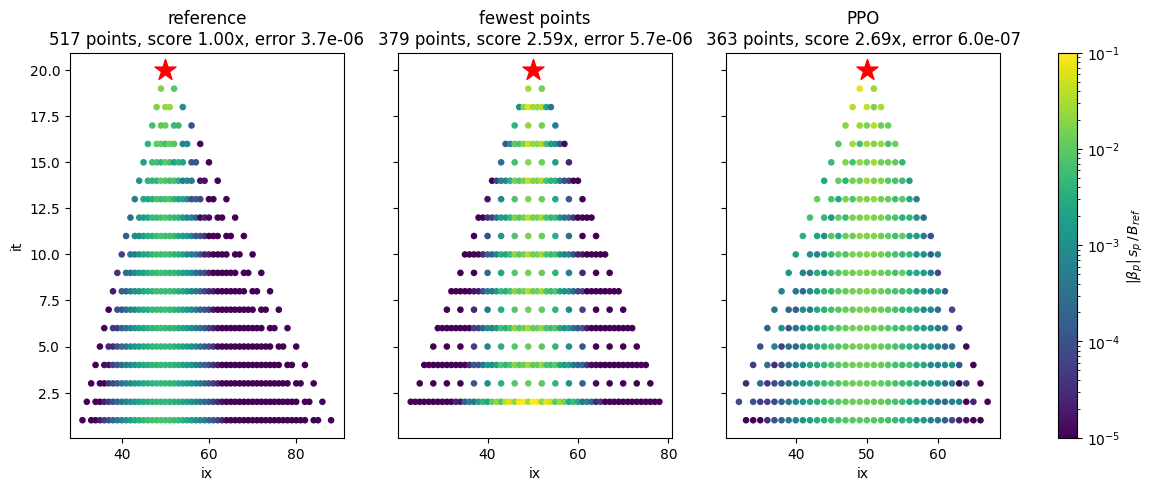

In [ ]:
from matplotlib.colors import LogNorm

def terms(m):
    """Each computed point's share of the score sum, relative to the reference."""
    B_ref, _ = reference(m["z_star"])
    return {p: abs(m["beta"][p]) * score(*p, nbs, w) / B_ref for p, (nbs, w) in m["stencil"].items()}

norm = LogNorm(vmin=1e-5, vmax=1e-1)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, (name, m) in zip(axes, maps.items()):
    T = terms(m)
    sc = ax.scatter([p[0] for p in T], [p[1] for p in T], c=list(T.values()), cmap="viridis", norm=norm, s=14)
    ax.scatter(*Z_HARD, marker="*", s=250, c="red")
    ax.set_title(f"{name}\n{len(T)} points, score {sum(T.values()):.2f}x, error {true_error(m):.1e}")
    ax.set_xlabel("ix")
axes[0].set_ylabel("it")
fig.colorbar(sc, ax=axes, label=r"$|\beta_p|\,s_p\,/\,B_{ref}$")
plt.show()

In [ ]:
# ── Equidistribution: how evenly is the score spread over the points each map pays for? ──
print(f"{'':14s} points   spread of log10(term)   points with term < 1% of the average")
for name, m in maps.items():
    T = np.array(list(terms(m).values()))
    wasted = np.mean(T < 0.01 * T.mean())
    print(f"{name:14s} {len(T):5d}        {np.std(np.log10(T)):.2f}                  {wasted:.0%}")

               points   spread of log10(term)   points with term < 1% of the average
reference        517        3.41                  35%
fewest points    379        2.74                  40%
PPO              363        0.93                  7%


In [ ]:
# ── PPO from scratch at z* = (50, 20), lam = 8: success rate over more seeds ──
SEEDS = [3, 4, 5, 6, 7]
TOTAL = 3_000_000

for seed in SEEDS:
    vec   = SubprocVecEnv([make_env([Z_HARD], LAM_HARD, 100 * seed + i) for i in range(N_ENVS)])
    model = MaskablePPO("MlpPolicy", vec, n_steps=256, batch_size=256, gamma=1.0, seed=seed, verbose=0)
    log   = EpisodeLog()
    t0 = time.time()
    model.learn(total_timesteps=TOTAL, callback=log)
    vec.close()
    model.save(f"local_reward_{Z_HARD[0]}_{Z_HARD[1]}_lam{LAM_HARD:.0f}_seed{seed}_{date.today()}")

    tot, info, e_s = evaluate_policy(model, Z_HARD, LAM_HARD)
    T = np.array(list(terms(e_s.m).values()))
    results[seed] = {"return": tot, "points": info["n_points"], "error": info["error"], "bound": exact_bound(e_s.m),
                     "spread": np.std(np.log10(T)), "wasted": np.mean(T < 0.01 * T.mean())}
    eps, n = log.episodes, max(1, len(log.episodes) // 4)
    curve = "  ".join(f"{np.mean([x['n_points'] for x in eps[k:k + n]]):.0f} pts/{np.mean([x['score_ratio'] for x in eps[k:k + n]]):.2f}x"
                      for k in range(0, len(eps), n))
    print(f"seed {seed}: {time.time() - t0:.0f} s | return {tot:.2f} | curve: {curve}")

print(f"\nz* = {Z_HARD}, lam = {LAM_HARD}   (fewest points: return -8.44, 379 points, bound 1.22e-05, spread 2.74, wasted 40%)")
print(f"{'seed':>4s}  {'return':>7s}  {'points':>6s}  {'true error':>10s}  {'exact bound':>11s}  {'spread':>6s}  {'wasted':>6s}")
for seed, r in sorted(results.items()):
    print(f"{seed:4d}  {r['return']:7.2f}  {r['points']:6d}  {r['error']:10.2e}  {r['bound']:11.2e}  {r['spread']:6.2f}  {r['wasted']:6.0%}")
wins = sum(r["return"] > -8.44 for r in results.values())
print(f"\nbeat every heuristic in {wins} of {len(results)} runs")

seed 1 done in 631 s
seed 2 done in 627 s

z* = (50, 20), lam = 8.0   (fewest points: return -8.44, 379 points, bound 1.22e-05, spread 2.74, wasted 40%)
seed   return  points  true error  exact bound  spread  wasted
   0    -8.29     363    6.00e-07     6.27e-06    0.93      7%
   1   -11.59     585    1.24e-05     1.29e-05    3.38     38%
   2   -15.04     658    2.65e-05     2.72e-05    4.67     46%


In [ ]:
# ── PPO from scratch at z* = (50, 20), lam = 8: seeds 3-5, progress every 100k steps ──
SEEDS = [3, 4, 5]
TOTAL = 3_000_000

class ProgressLog(EpisodeLog):
    """EpisodeLog that also prints a status line every `every` steps."""
    def __init__(self, every=100_000):
        super().__init__()
        self.every, self.next_print, self.t0 = every, every, time.time()
    def _on_step(self):
        super()._on_step()
        if self.num_timesteps >= self.next_print:
            recent = self.episodes[-20:]
            if recent:
                print(f"   {self.num_timesteps / 1e6:4.1f}M steps | {len(self.episodes):4d} episodes | "
                      f"last 20: {np.mean([x['n_points'] for x in recent]):5.0f} pts, score {np.mean([x['score_ratio'] for x in recent]):5.2f}x "
                      f"| {time.time() - self.t0:4.0f} s")
            self.next_print += self.every
        return True

for seed in SEEDS:
    print(f"seed {seed}")
    vec   = SubprocVecEnv([make_env([Z_HARD], LAM_HARD, 100 * seed + i) for i in range(N_ENVS)])
    model = MaskablePPO("MlpPolicy", vec, n_steps=256, batch_size=256, gamma=1.0, seed=seed, verbose=0)
    log   = ProgressLog()
    model.learn(total_timesteps=TOTAL, callback=log)
    vec.close()
    model.save(f"local_reward_{Z_HARD[0]}_{Z_HARD[1]}_lam{LAM_HARD:.0f}_seed{seed}_{date.today()}")

    tot, info, e_s = evaluate_policy(model, Z_HARD, LAM_HARD)
    T = np.array(list(terms(e_s.m).values()))
    results[seed] = {"return": tot, "points": info["n_points"], "error": info["error"], "bound": exact_bound(e_s.m),
                     "spread": np.std(np.log10(T)), "wasted": np.mean(T < 0.01 * T.mean())}
    print(f"seed {seed} final: return {tot:.2f}, {info['n_points']} points\n")

print(f"z* = {Z_HARD}, lam = {LAM_HARD}   (fewest points: return -8.44, 379 points, bound 1.22e-05, spread 2.74, wasted 40%)")
print(f"{'seed':>4s}  {'return':>7s}  {'points':>6s}  {'true error':>10s}  {'exact bound':>11s}  {'spread':>6s}  {'wasted':>6s}")
for seed, r in sorted(results.items()):
    print(f"{seed:4d}  {r['return']:7.2f}  {r['points']:6d}  {r['error']:10.2e}  {r['bound']:11.2e}  {r['spread']:6.2f}  {r['wasted']:6.0%}")
wins = sum(r["return"] > -8.44 for r in results.values())
print(f"\nbeat every heuristic in {wins} of {len(results)} runs")

seed 3
    0.1M steps |   40 episodes | last 20:   457 pts, score 10.90x |   21 s
    0.2M steps |   96 episodes | last 20:   408 pts, score  2.97x |   43 s
    0.3M steps |  149 episodes | last 20:   403 pts, score  2.76x |   63 s
    0.4M steps |  204 episodes | last 20:   408 pts, score  2.87x |   84 s
    0.5M steps |  259 episodes | last 20:   421 pts, score  3.14x |  105 s
    0.6M steps |  312 episodes | last 20:   403 pts, score  2.86x |  126 s
    0.7M steps |  368 episodes | last 20:   403 pts, score  3.00x |  147 s
    0.8M steps |  420 episodes | last 20:   403 pts, score  2.92x |  167 s
    0.9M steps |  477 episodes | last 20:   415 pts, score  3.08x |  189 s
    1.0M steps |  528 episodes | last 20:   411 pts, score  3.02x |  210 s
    1.1M steps |  577 episodes | last 20:   460 pts, score  3.14x |  232 s
    1.2M steps |  623 episodes | last 20:   518 pts, score  2.95x |  253 s
    1.3M steps |  658 episodes | last 20:   645 pts, score  2.67x |  274 s
    1.4M steps |  

In [14]:
# ── State fix: let the agent see the work still pending ──
class PendingStateEnv(ScoreStateEnv):
    """ScoreStateEnv plus the pending workload: how many points still need a stencil, and their total influence."""
    N_EXTRA = 2
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(N_OBS + N_CELLS + self.N_EXTRA,), dtype=np.float32)

    def _obs(self):
        if not self.m["pending"]:
            return np.zeros(N_OBS + N_CELLS + self.N_EXTRA, np.float32)
        pend = [(ix, -neg_it) for neg_it, ix in self.m["pending"]]
        extra = [len(pend) / self.N_ref,                                   # points still waiting
                 sum(abs(self.m["beta"][q]) for q in pend)]               # their total influence on z*
        return np.concatenate([super()._obs(), extra]).astype(np.float32)

def make_env_cls(cls, queries, lam, seed):
    def _init():
        env = Monitor(cls(queries=queries, lam=lam))
        env.reset(seed=seed)
        return env
    return _init

def evaluate_cls(cls, model, z, lam):
    e = cls(queries=[z], lam=lam); o, _ = e.reset(seed=0); d = False; tot = 0.0
    while not d:
        a, _ = model.predict(o, action_masks=e.action_masks(), deterministic=True)
        o, r, d, _, info = e.step(a); tot += r
    return tot, info, e

e26 = PendingStateEnv(queries=[Z_HARD], lam=LAM_HARD); o, _ = e26.reset(seed=0)
for k in range(30):
    o, r, d, _, _ = e26.step(np.flatnonzero(e26.action_masks())[0])
print("obs size:", o.shape[0], "| pending points / N_ref:", round(float(o[-2]), 3), "| pending influence:", round(float(o[-1]), 3))

NameError: name 'ScoreStateEnv' is not defined

In [ ]:
# ── Seeds 1, 2, 3 (all failed before) with the pending workload in the state ──
SEEDS, TOTAL = [1, 2, 3], 3_000_000
results_pending = {}

for seed in SEEDS:
    print(f"seed {seed}")
    vec   = SubprocVecEnv([make_env_cls(PendingStateEnv, [Z_HARD], LAM_HARD, 100 * seed + i) for i in range(N_ENVS)])
    model = MaskablePPO("MlpPolicy", vec, n_steps=256, batch_size=256, gamma=1.0, seed=seed, verbose=0)
    model.learn(total_timesteps=TOTAL, callback=ProgressLog())
    vec.close()
    model.save(f"local_reward_pending_{Z_HARD[0]}_{Z_HARD[1]}_lam{LAM_HARD:.0f}_seed{seed}_{date.today()}")

    tot, info, e_s = evaluate_cls(PendingStateEnv, model, Z_HARD, LAM_HARD)
    T = np.array(list(terms(e_s.m).values()))
    results_pending[seed] = {"return": tot, "points": info["n_points"], "error": info["error"], "bound": exact_bound(e_s.m),
                             "spread": np.std(np.log10(T)), "wasted": np.mean(T < 0.01 * T.mean())}
    print(f"seed {seed} final: return {tot:.2f}, {info['n_points']} points\n")

print(f"z* = {Z_HARD}, lam = {LAM_HARD}   (fewest points: return -8.44, 379 points)")
print(f"{'seed':>4s}  {'before':>7s}  {'after':>7s}  {'points':>6s}  {'true error':>10s}  {'exact bound':>11s}  {'spread':>6s}  {'wasted':>6s}")
for seed, r in results_pending.items():
    print(f"{seed:4d}  {results[seed]['return']:7.2f}  {r['return']:7.2f}  {r['points']:6d}  {r['error']:10.2e}  "
          f"{r['bound']:11.2e}  {r['spread']:6.2f}  {r['wasted']:6.0%}")

seed 1
    0.1M steps |   41 episodes | last 20:   434 pts, score  5.84x |   21 s
    0.2M steps |   96 episodes | last 20:   411 pts, score  2.87x |   42 s
    0.3M steps |  152 episodes | last 20:   411 pts, score  2.79x |   63 s
    0.4M steps |  204 episodes | last 20:   427 pts, score  2.88x |   84 s
    0.5M steps |  252 episodes | last 20:   438 pts, score  2.86x |  105 s
    0.6M steps |  306 episodes | last 20:   438 pts, score  2.76x |  126 s
    0.7M steps |  358 episodes | last 20:   449 pts, score  2.78x |  146 s
    0.8M steps |  407 episodes | last 20:   455 pts, score  2.86x |  168 s
    0.9M steps |  455 episodes | last 20:   472 pts, score  2.85x |  188 s
    1.0M steps |  500 episodes | last 20:   493 pts, score  2.86x |  209 s
    1.1M steps |  540 episodes | last 20:   518 pts, score  2.76x |  230 s
    1.2M steps |  582 episodes | last 20:   568 pts, score  2.73x |  253 s
    1.3M steps |  623 episodes | last 20:   577 pts, score  2.62x |  280 s
    1.4M steps |  

In [ ]:
# ── Generalisation: the seed-2 model (trained only on z* = (50, 20)) on queries it has never seen ──
import glob
path  = sorted(glob.glob(f"local_reward_pending_{Z_HARD[0]}_{Z_HARD[1]}_lam{LAM_HARD:.0f}_seed2_*.zip"))[-1]
model = MaskablePPO.load(path)
print("loaded", path)

choose_min = lambda m, p: min(admissible_sets(*p), key=lambda s: (n_new_points(m, p, s), s_of(p, s)))
QUERIES = [(50, 10), (50, 15), (50, 20), (50, 25), (50, 30), (30, 20), (70, 20)]

print(f"\nlam = {LAM_HARD}          PPO (ret / pts)   best rule (ret / pts / which)      FD pts   PPO bound   FD error")
for z in QUERIES:
    B_ref, N_ref = reference(z)
    tot, info, e_z = evaluate_cls(PendingStateEnv, model, z, LAM_HARD)
    best = None
    for name, ch in [("reference", choose_ref), ("greedy", make_greedy(B_ref, N_ref, LAM_HARD)), ("fewest", choose_min)]:
        _, B_b, N_b = build_map(z, ch)
        r = -B_b / B_ref - LAM_HARD * (N_b - 1) / N_ref
        if best is None or r > best[0]:
            best = (r, N_b, name)
    flag = "  <- PPO wins" if tot > best[0] else ""
    print(f"z* = {str(z):9s}  {tot:7.2f} / {info['n_points']:4d}    {best[0]:7.2f} / {best[1]:4d} / {best[2]:9s}   "
          f"{fd_reference(*z)[2]:5d}   {exact_bound(e_z.m):.1e}   {fd_reference(*z)[1]:.1e}{flag}")

loaded local_reward_pending_50_20_lam8_seed2_2026-09-30.zip

lam = 8.0          PPO (ret / pts)   best rule (ret / pts / which)      FD pts   PPO bound   FD error
z* = (50, 10)     -8.62 /   91      -8.93 /  112 / reference     100   3.6e-06   2.6e-05  <- PPO wins
z* = (50, 15)     -8.29 /  209      -8.35 /  223 / fewest        225   5.5e-06   3.9e-05  <- PPO wins
z* = (50, 20)     -8.23 /  378      -8.44 /  379 / fewest        400   7.8e-06   5.2e-05  <- PPO wins
z* = (50, 25)     -8.74 /  653      -8.03 /  623 / fewest        625   1.0e-05   6.5e-05
z* = (50, 30)     -9.51 / 1049      -8.23 /  869 / fewest        900   1.3e-05   7.8e-05
z* = (30, 20)     -8.23 /  378      -8.44 /  379 / fewest        400   1.0e-05   4.8e-05  <- PPO wins
z* = (70, 20)     -8.42 /  378      -8.63 /  379 / fewest        400   6.2e-06   2.0e-06  <- PPO wins


In [13]:
# ── Same as Cell 27 (pending workload in the state), plus gae_lambda = 1.0 ──
SEEDS, TOTAL = [1, 2, 3], 3_000_000
results_gae = {}

for seed in SEEDS:
    print(f"seed {seed}")
    vec   = SubprocVecEnv([make_env_cls(PendingStateEnv, [Z_HARD], LAM_HARD, 100 * seed + i) for i in range(N_ENVS)])
    model = MaskablePPO("MlpPolicy", vec, n_steps=256, batch_size=256, gamma=1.0, gae_lambda=1.0, seed=seed, verbose=0)
    model.learn(total_timesteps=TOTAL, callback=ProgressLog())
    vec.close()
    model.save(f"local_reward_pending_gae1_{Z_HARD[0]}_{Z_HARD[1]}_lam{LAM_HARD:.0f}_seed{seed}_{date.today()}")

    tot, info, e_s = evaluate_cls(PendingStateEnv, model, Z_HARD, LAM_HARD)
    T = np.array(list(terms(e_s.m).values()))
    results_gae[seed] = {"return": tot, "points": info["n_points"], "error": info["error"], "bound": exact_bound(e_s.m),
                         "spread": np.std(np.log10(T)), "wasted": np.mean(T < 0.01 * T.mean())}
    print(f"seed {seed} final: return {tot:.2f}, {info['n_points']} points\n")

fmt = lambda d, s: f"{d[s]['return']:7.2f}" if s in d else "      -"
print(f"z* = {Z_HARD}, lam = {LAM_HARD}   (fewest points: return -8.44, 379 points)")
print(f"{'seed':>4s}  {'scratch':>7s}  {'pending':>7s}  {'+gae1':>7s}  {'points':>6s}  {'exact bound':>11s}  {'spread':>6s}  {'wasted':>6s}")
for seed, r in results_gae.items():
    print(f"{seed:4d}  {fmt(results, seed)}  {fmt(results_pending, seed)}  {r['return']:7.2f}  {r['points']:6d}  "
          f"{r['bound']:11.2e}  {r['spread']:6.2f}  {r['wasted']:6.0%}")

seed 1


NameError: name 'N_ENVS' is not defined

---------------------------------------------

In [34]:
# ── Restore: definitions from Cells 12, 14, 17, 20, 21, 25 without re-running any training ──
import time
from matplotlib.colors import LogNorm

class EpisodeLog(BaseCallback):
    """Keeps the info of every finished episode."""
    def __init__(self):
        super().__init__()
        self.episodes = []
    def _on_step(self):
        for info, done in zip(self.locals["infos"], self.locals["dones"]):
            if done:
                self.episodes.append(info)
        return True

class ProgressLog(EpisodeLog):
    """EpisodeLog that also prints a status line every `every` steps."""
    def __init__(self, every=100_000):
        super().__init__()
        self.every, self.next_print, self.t0 = every, every, time.time()
    def _on_step(self):
        super()._on_step()
        if self.num_timesteps >= self.next_print:
            recent = self.episodes[-20:]
            if recent:
                print(f"   {self.num_timesteps / 1e6:4.1f}M steps | {len(self.episodes):4d} episodes | "
                      f"last 20: {np.mean([x['n_points'] for x in recent]):5.0f} pts, score {np.mean([x['score_ratio'] for x in recent]):5.2f}x "
                      f"| {time.time() - self.t0:4.0f} s")
            self.next_print += self.every
        return True

Z_TRAIN, LAM        = (50, 10), 1.0
Z_HARD,  LAM_HARD   = (50, 20), 8.0
N_ENVS              = 12

def terms(m):
    """Each computed point's share of the score sum, relative to the reference."""
    B_ref, _ = reference(m["z_star"])
    return {p: abs(m["beta"][p]) * score(*p, nbs, w) / B_ref for p, (nbs, w) in m["stencil"].items()}

def exact_bound(m):
    """sum over points of |beta_p * delta_p|: the true error with no cancellation allowed (u_true, checking only)."""
    U = lambda q: u_true(q[0] * dx, q[1] * dt)[0]
    return sum(abs(m["beta"][p] * (U(p) - sum(wq * U(q) for q, wq in zip(nbs, w)))) for p, (nbs, w) in m["stencil"].items())

choose_min = lambda m, p: min(admissible_sets(*p), key=lambda s: (n_new_points(m, p, s), s_of(p, s)))

# returns recorded so far at z* = (50, 20), lam = 8 (Cells 20, 23, 25, 27)
results         = {s: {"return": r} for s, r in {0: -8.29, 1: -11.59, 2: -15.04, 3: -14.39, 4: -13.49, 5: -14.36}.items()}
results_pending = {s: {"return": r} for s, r in {1: -13.52, 2: -8.23, 3: -14.05}.items()}
print("restored")

restored


In [32]:
# ── Score in the state: for each cell, the best stencil score still reachable if it is picked next ──
_scored_cache = {}
def scored_sets(ix, it):
    """For every admissible stencil at (ix, it): which cells it uses (bool matrix) and log10 of its
    score relative to the best one here. Cached per local situation."""
    key = tuple((q[0] - ix, q[1] - it) for q in (place(ix, it, a) for a in range(N_CELLS)))
    if key not in _scored_cache:
        sets = admissible_sets(ix, it)
        uses = np.zeros((len(sets), N_CELLS), dtype=bool)
        for k, s in enumerate(sets):
            uses[k, list(s)] = True
        logs = np.log10([s_of((ix, it), s) for s in sets])
        _scored_cache[key] = (uses, logs - logs.min())
    return _scored_cache[key]

def reachable_score(ix, it, picks):
    """Per cell: log10(best score reachable with picks + that cell / best score at this point).
    0 = the best stencil is still reachable through this cell. Cells that can't be picked get the cap 3."""
    uses, rel = scored_sets(ix, it)
    ok = uses[:, picks].all(axis=1) if picks else np.ones(len(rel), dtype=bool)   # stencils still reachable
    out = np.where(uses[ok], rel[ok, None], 3.0).min(axis=0) if ok.any() else np.full(N_CELLS, 3.0)
    out[picks] = 3.0                                                               # already picked
    return np.minimum(out, 3.0)

class ScoreStateEnv(LocalRewardEnv):
    """LocalRewardEnv plus one number per window cell: how good a stencil can still be built through it."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(N_OBS + N_CELLS,), dtype=np.float32)

    def _obs(self):
        if not self.m["pending"]:
            return np.zeros(N_OBS + N_CELLS, np.float32)
        extra = reachable_score(*next_point(self.m), self.picks)
        return np.concatenate([super()._obs(), extra]).astype(np.float32)

# check at (50, 10): before any pick, and after picking cell 0
print("before any pick:  ", np.round(reachable_score(50, 10, []), 2))
print("after picking 0:  ", np.round(reachable_score(50, 10, [0]), 2))
e16 = ScoreStateEnv(queries=[Z_TRAIN]); o, _ = e16.reset(seed=0)
print("obs size:", o.shape[0])

before any pick:   [0.06 0.   0.16 0.06 0.   0.   0.06 0.   0.   0.06]
after picking 0:   [3.   0.2  0.16 0.06 0.16 0.38 0.06 0.06 0.16 0.06]
obs size: 45


In [33]:
# ── State fix: let the agent see the work still pending ──
class PendingStateEnv(ScoreStateEnv):
    """ScoreStateEnv plus the pending workload: how many points still need a stencil, and their total influence."""
    N_EXTRA = 2
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(N_OBS + N_CELLS + self.N_EXTRA,), dtype=np.float32)

    def _obs(self):
        if not self.m["pending"]:
            return np.zeros(N_OBS + N_CELLS + self.N_EXTRA, np.float32)
        pend = [(ix, -neg_it) for neg_it, ix in self.m["pending"]]
        extra = [len(pend) / self.N_ref,                                   # points still waiting
                 sum(abs(self.m["beta"][q]) for q in pend)]               # their total influence on z*
        return np.concatenate([super()._obs(), extra]).astype(np.float32)

def make_env_cls(cls, queries, lam, seed):
    def _init():
        env = Monitor(cls(queries=queries, lam=lam))
        env.reset(seed=seed)
        return env
    return _init

def evaluate_cls(cls, model, z, lam):
    e = cls(queries=[z], lam=lam); o, _ = e.reset(seed=0); d = False; tot = 0.0
    while not d:
        a, _ = model.predict(o, action_masks=e.action_masks(), deterministic=True)
        o, r, d, _, info = e.step(a); tot += r
    return tot, info, e

e26 = PendingStateEnv(queries=[Z_HARD], lam=LAM_HARD); o, _ = e26.reset(seed=0)
for k in range(30):
    o, r, d, _, _ = e26.step(np.flatnonzero(e26.action_masks())[0])
print("obs size:", o.shape[0], "| pending points / N_ref:", round(float(o[-2]), 3), "| pending influence:", round(float(o[-1]), 3))

obs size: 47 | pending points / N_ref: 0.017 | pending influence: 1.0


In [35]:
# ── Same as Cell 27 (pending workload in the state), plus gae_lambda = 1.0 ──
SEEDS, TOTAL = [1, 2, 3], 3_000_000
results_gae = {}

for seed in SEEDS:
    print(f"seed {seed}")
    vec   = SubprocVecEnv([make_env_cls(PendingStateEnv, [Z_HARD], LAM_HARD, 100 * seed + i) for i in range(N_ENVS)])
    model = MaskablePPO("MlpPolicy", vec, n_steps=256, batch_size=256, gamma=1.0, gae_lambda=1.0, seed=seed, verbose=0)
    model.learn(total_timesteps=TOTAL, callback=ProgressLog())
    vec.close()
    model.save(f"local_reward_pending_gae1_{Z_HARD[0]}_{Z_HARD[1]}_lam{LAM_HARD:.0f}_seed{seed}_{date.today()}")

    tot, info, e_s = evaluate_cls(PendingStateEnv, model, Z_HARD, LAM_HARD)
    T = np.array(list(terms(e_s.m).values()))
    results_gae[seed] = {"return": tot, "points": info["n_points"], "error": info["error"], "bound": exact_bound(e_s.m),
                         "spread": np.std(np.log10(T)), "wasted": np.mean(T < 0.01 * T.mean())}
    print(f"seed {seed} final: return {tot:.2f}, {info['n_points']} points\n")

fmt = lambda d, s: f"{d[s]['return']:7.2f}" if s in d else "      -"
print(f"z* = {Z_HARD}, lam = {LAM_HARD}   (fewest points: return -8.44, 379 points)")
print(f"{'seed':>4s}  {'scratch':>7s}  {'pending':>7s}  {'+gae1':>7s}  {'points':>6s}  {'exact bound':>11s}  {'spread':>6s}  {'wasted':>6s}")
for seed, r in results_gae.items():
    print(f"{seed:4d}  {fmt(results, seed)}  {fmt(results_pending, seed)}  {r['return']:7.2f}  {r['points']:6d}  "
          f"{r['bound']:11.2e}  {r['spread']:6.2f}  {r['wasted']:6.0%}")

seed 1
    0.1M steps |   36 episodes | last 20:   482 pts, score 23.52x |   22 s
    0.2M steps |   87 episodes | last 20:   428 pts, score  8.82x |   43 s
    0.3M steps |  144 episodes | last 20:   411 pts, score  5.61x |   63 s
    0.4M steps |  200 episodes | last 20:   398 pts, score  4.34x |   84 s
    0.5M steps |  252 episodes | last 20:   390 pts, score  3.14x |  105 s
    0.6M steps |  312 episodes | last 20:   393 pts, score  2.89x |  125 s
    0.7M steps |  369 episodes | last 20:   393 pts, score  2.82x |  146 s
    0.8M steps |  420 episodes | last 20:   392 pts, score  2.84x |  166 s
    0.9M steps |  480 episodes | last 20:   389 pts, score  2.84x |  187 s
    1.0M steps |  540 episodes | last 20:   386 pts, score  2.80x |  208 s
    1.1M steps |  596 episodes | last 20:   384 pts, score  2.82x |  229 s
    1.2M steps |  649 episodes | last 20:   382 pts, score  2.79x |  250 s
    1.3M steps |  708 episodes | last 20:   380 pts, score  2.76x |  271 s
    1.4M steps |  

In [36]:
# ── One model for many queries: train on 15, test on 6 it has never seen ──
TRAIN_Q = [(x, t) for t in (10, 15, 20, 25, 30) for x in (30, 50, 70)]
TEST_Q  = [(40, 12), (60, 18), (40, 22), (60, 28), (50, 35), (50, 40)]     # last two: longer than any training query
LAM_MQ, SEED, TOTAL = 8.0, 1, 10_000_000

t0 = time.time()
for z in TRAIN_Q + TEST_Q:
    reference(z)                     # computed once here, then copied to every worker process
print(f"reference maps for {len(TRAIN_Q) + len(TEST_Q)} queries: {time.time() - t0:.0f} s")

class MultiProgressLog(EpisodeLog):
    """Every `every` steps: points and score relative to each query's own reference map (last 50 episodes)."""
    def __init__(self, every=500_000):
        super().__init__()
        self.every, self.next_print, self.t0 = every, every, time.time()
    def _on_step(self):
        super()._on_step()
        if self.num_timesteps >= self.next_print:
            recent = self.episodes[-50:]
            if recent:
                print(f"   {self.num_timesteps / 1e6:4.1f}M steps | {len(self.episodes):5d} episodes | last 50: "
                      f"points {np.mean([x['points_ratio'] for x in recent]):.2f}x ref, score {np.mean([x['score_ratio'] for x in recent]):.2f}x ref "
                      f"| {time.time() - self.t0:5.0f} s")
            self.next_print += self.every
        return True

vec   = SubprocVecEnv([make_env_cls(PendingStateEnv, TRAIN_Q, LAM_MQ, 100 * SEED + i) for i in range(N_ENVS)])
model = MaskablePPO("MlpPolicy", vec, n_steps=256, batch_size=256, gamma=1.0, gae_lambda=1.0, seed=SEED, verbose=0)
model.learn(total_timesteps=TOTAL, callback=MultiProgressLog())
vec.close()
model.save(f"local_reward_multi_lam{LAM_MQ:.0f}_seed{SEED}_{date.today()}")

# evaluation: PPO against the best heuristic on every query
def compare(z):
    B_ref, N_ref = reference(z)
    tot, info, e_z = evaluate_cls(PendingStateEnv, model, z, LAM_MQ)
    best = None
    for name, ch in [("reference", choose_ref), ("greedy", make_greedy(B_ref, N_ref, LAM_MQ)), ("fewest", choose_min)]:
        _, B_b, N_b = build_map(z, ch)
        r = -B_b / B_ref - LAM_MQ * (N_b - 1) / N_ref
        if best is None or r > best[0]:
            best = (r, N_b, name)
    return tot, info["n_points"], best, exact_bound(e_z.m)

wins = {"train": 0, "test": 0}
print(f"\nlam = {LAM_MQ}               PPO (ret / pts)   best rule (ret / pts / which)      FD pts   PPO bound   FD error")
for label, queries in [("train", TRAIN_Q), ("test", TEST_Q)]:
    for z in queries:
        tot, n_pts, best, bound = compare(z)
        win = tot > best[0]
        wins[label] += win
        print(f"{label:5s} z* = {str(z):9s}  {tot:7.2f} / {n_pts:4d}    {best[0]:7.2f} / {best[1]:4d} / {best[2]:9s}   "
              f"{fd_reference(*z)[2]:5d}   {bound:.1e}   {fd_reference(*z)[1]:.1e}{'  <- PPO wins' if win else ''}")
print(f"\nPPO beats every heuristic on {wins['train']}/{len(TRAIN_Q)} training queries and {wins['test']}/{len(TEST_Q)} unseen queries")

reference maps for 21 queries: 37 s
    0.5M steps |   206 episodes | last 50: points 0.81x ref, score 5.95x ref |   105 s
    1.0M steps |   491 episodes | last 50: points 0.61x ref, score 5.48x ref |   210 s
    1.5M steps |   850 episodes | last 50: points 0.51x ref, score 5.06x ref |   312 s
    2.0M steps |  1244 episodes | last 50: points 0.51x ref, score 5.08x ref |   412 s
    2.5M steps |  1657 episodes | last 50: points 0.48x ref, score 4.98x ref |   512 s
    3.0M steps |  2051 episodes | last 50: points 0.48x ref, score 5.02x ref |   612 s
    3.5M steps |  2469 episodes | last 50: points 0.45x ref, score 5.07x ref |   715 s
    4.0M steps |  2902 episodes | last 50: points 0.46x ref, score 5.06x ref |   818 s
    4.5M steps |  3337 episodes | last 50: points 0.45x ref, score 5.11x ref |   922 s
    5.0M steps |  3787 episodes | last 50: points 0.43x ref, score 5.08x ref |  1027 s
    5.5M steps |  4246 episodes | last 50: points 0.45x ref, score 5.01x ref |  1131 s
    6.0

NameError: name 'glob' is not defined

      query       FD pts   FD error   FD bound  |  PPO pts   PPO bound   bound ratio FD/PPO
train (30, 10)       100   2.5e-05   2.5e-05   |       55   2.7e-06        9.2x
train (50, 10)       100   2.6e-05   2.6e-05   |       55   1.2e-05        2.1x
train (70, 10)       100   1.8e-07   2.1e-06   |       55   8.9e-06        0.2x
train (30, 15)       225   3.7e-05   3.7e-05   |      120   4.5e-06        8.2x
train (50, 15)       225   3.9e-05   3.9e-05   |      120   1.8e-05        2.2x
train (70, 15)       225   8.9e-07   3.9e-06   |      120   1.4e-05        0.3x
train (30, 20)       400   4.8e-05   4.8e-05   |      210   6.6e-06        7.3x
train (50, 20)       400   5.2e-05   5.2e-05   |      210   2.4e-05        2.2x
train (70, 20)       400   2.0e-06   6.2e-06   |      210   1.8e-05        0.3x
train (30, 25)       625   5.9e-05   5.9e-05   |      325   9.0e-06        6.6x
train (50, 25)       625   6.5e-05   6.5e-05   |      325   2.9e-05        2.2x
train (70, 25)       625   3

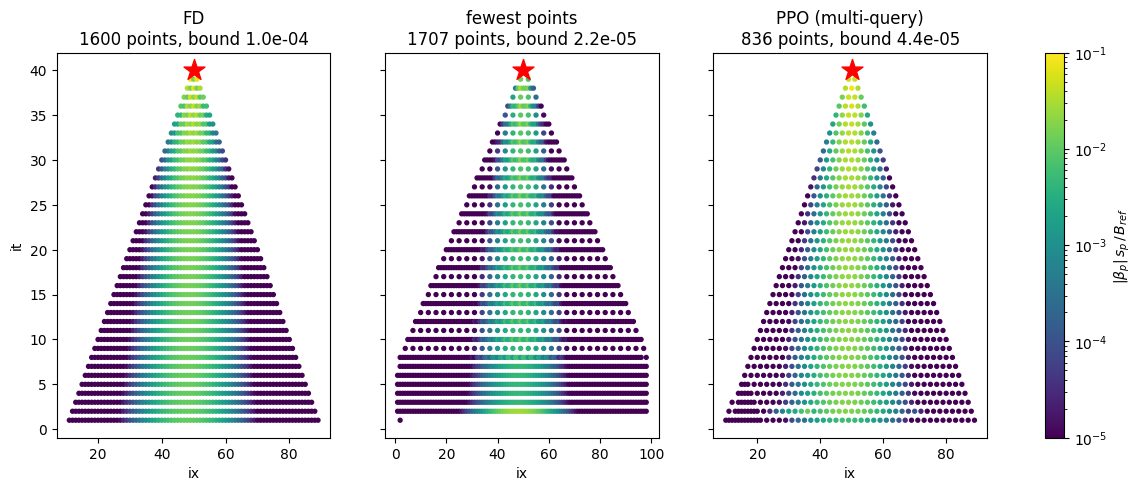

PPO at (50, 40): neighbours one level down 43%, two levels down 57% | uses 40 of 40 time levels


In [39]:
# ── Fair error comparison (FD's exact bound) and a look at the maps ──
def fd_map(z):
    """FD's cone as a map in our format: 3-point stencils one level down, influence passed down from z*."""
    zx, zt = z
    m = {"z_star": z, "beta": {z: 1.0}, "stencil": {}, "pending": []}
    for it in range(zt, 0, -1):                                   # top-down, so each beta is complete when used
        for ix in range(max(1, zx - (zt - it)), min(nx - 2, zx + (zt - it)) + 1):
            p = (ix, it)
            nbs = [(ix - 1, it - 1), (ix, it - 1), (ix + 1, it - 1)]
            m["stencil"][p] = (nbs, W_FD)
            for q, wq in zip(nbs, W_FD):
                if not is_known(*q):
                    m["beta"][q] = m["beta"].get(q, 0.0) + m["beta"][p] * wq
    return m

assert abs(true_error(fd_map((50, 20))) - fd_reference(50, 20)[1]) < 1e-12     # same numbers as the FD reference

print(f"{'':5s} {'query':9s}   FD pts   FD error   FD bound  |  PPO pts   PPO bound   bound ratio FD/PPO")
for label, queries in [("train", TRAIN_Q), ("test", TEST_Q)]:
    for z in queries:
        m_fd = fd_map(z)
        _, info, e_z = evaluate_cls(PendingStateEnv, model, z, LAM_MQ)
        b_fd, b_ppo = exact_bound(m_fd), exact_bound(e_z.m)
        print(f"{label:5s} {str(z):9s}   {len(m_fd['stencil']):6d}   {true_error(m_fd):.1e}   {b_fd:.1e}   |  {info['n_points']:7d}   {b_ppo:.1e}      {b_fd / b_ppo:5.1f}x")

# the maps at an unseen query
Z_SHOW = (50, 40)
_, _, e_show = evaluate_cls(PendingStateEnv, model, Z_SHOW, LAM_MQ)
maps = {"FD": fd_map(Z_SHOW), "fewest points": build_map(Z_SHOW, choose_min)[0], "PPO (multi-query)": e_show.m}
norm = LogNorm(vmin=1e-5, vmax=1e-1)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, (name, m) in zip(axes, maps.items()):
    T = terms(m)
    sc = ax.scatter([p[0] for p in T], [p[1] for p in T], c=list(T.values()), cmap="viridis", norm=norm, s=8)
    ax.scatter(*Z_SHOW, marker="*", s=250, c="red")
    ax.set_title(f"{name}\n{len(T)} points, bound {exact_bound(m):.1e}")
    ax.set_xlabel("ix")
axes[0].set_ylabel("it")
fig.colorbar(sc, ax=axes, label=r"$|\beta_p|\,s_p\,/\,B_{ref}$")
plt.show()

# how does PPO step through time? share of stencil neighbours one vs two levels down, and levels it uses
m = e_show.m
drops = [p[1] - q[1] for p, (nbs, w) in m["stencil"].items() for q in nbs]
levels = sorted({p[1] for p in m["stencil"]})
print(f"PPO at {Z_SHOW}: neighbours one level down {np.mean(np.array(drops) == 1):.0%}, two levels down {np.mean(np.array(drops) == 2):.0%} "
      f"| uses {len(levels)} of {Z_SHOW[1]} time levels")

In [40]:
m = e_show.m
same = np.mean([(p[0] + p[1]) % 2 == (Z_SHOW[0] + Z_SHOW[1]) % 2 for p in m["stencil"]])
print(f"points on z*'s checkerboard: {same:.0%}")

points on z*'s checkerboard: 98%


In [41]:
# ── Bigger action space: 21-cell window (|dix| <= 3, 3 levels down), reward measured against FD ──
R_X, K_T = 3, 3
WINDOW  = [(dix, dit) for dit in range(-1, -K_T - 1, -1) for dix in range(-R_X, R_X + 1)]
N_CELLS = len(WINDOW)
N_OBS   = 3 * N_CELLS + 5
for cache in (_w_cache, _sets_cache, _ref_cache):
    cache.clear()

_big = {}
def _situation(ix, it):
    return tuple((q[0] - ix, q[1] - it) for q in (place(ix, it, a) for a in range(N_CELLS)))

def big_sets(ix, it):
    """All admissible stencils here, checked in one vectorised pass: (list of sets, cell-usage matrix, scores)."""
    key = _situation(ix, it)
    if key not in _big:
        cells = distinct_cells(ix, it)
        combos = np.array(list(itertools.combinations(cells, min(N_NB, len(cells)))))
        offs = np.array(key, dtype=float)[combos]
        DX, DT = offs[..., 0] * dx, offs[..., 1] * dt
        h  = np.maximum(np.abs(DX).max(1), np.sqrt(alpha * np.abs(DT).max(1)))[:, None]
        xi = DX - c * DT
        A  = np.stack([np.ones_like(DX), xi / h, (0.5 * xi**2 + alpha * DT) / h**2], axis=1)
        sv = np.linalg.svd(A, compute_uv=False)
        ok = (sv[:, -1] > sv[:, 0] * 1e-12 * max(A.shape[1:])) & (sv[:, 0] <= COND_MAX * sv[:, -1])
        w  = np.linalg.pinv(A)[:, :, 0]
        ok &= np.abs(w).sum(1) <= W_MAX
        m3 = np.einsum('mk,mk->m', w, xi**3 + 6 * alpha * DT * xi)
        m4 = np.einsum('mk,mk->m', w, xi**4 + 12 * alpha * DT * xi**2 + 12 * (alpha * DT)**2)
        sc = np.abs(m3) / (6 * L_SOL**3) + np.abs(m4) / (24 * L_SOL**4)
        uses = np.zeros((ok.sum(), N_CELLS), dtype=bool)
        np.put_along_axis(uses, combos[ok], True, axis=1)
        _big[key] = ([tuple(cm) for cm in combos[ok]], uses, sc[ok])
    return _big[key]

admissible_sets = lambda ix, it: big_sets(ix, it)[0]

def choose_ref(m, p):
    sets, _, sc = big_sets(*p)
    return sets[int(np.argmin(sc))]

def pick_mask(ix, it, picks):
    """Vectorised: cell a is allowed if some admissible stencil contains the picks so far plus a."""
    _, uses, _ = big_sets(ix, it)
    ok = uses[:, picks].all(axis=1) if picks else np.ones(len(uses), dtype=bool)
    mask = uses[ok].any(axis=0)
    mask[picks] = False
    return mask

def reachable_score(ix, it, picks):
    _, uses, sc = big_sets(ix, it)
    rel = np.log10(sc) - np.log10(sc).min()
    ok = uses[:, picks].all(axis=1) if picks else np.ones(len(rel), dtype=bool)
    out = np.where(uses[ok], rel[ok, None], 3.0).min(axis=0) if ok.any() else np.full(N_CELLS, 3.0)
    out[picks] = 3.0
    return np.minimum(out, 3.0)

def fd_map(z):
    """FD's cone as a map in our format: 3-point stencils one level down, influence passed down from z*."""
    zx, zt = z
    m = {"z_star": z, "beta": {z: 1.0}, "stencil": {}, "pending": []}
    for it in range(zt, 0, -1):
        for ix in range(max(1, zx - (zt - it)), min(nx - 2, zx + (zt - it)) + 1):
            p = (ix, it)
            nbs = [(ix - 1, it - 1), (ix, it - 1), (ix + 1, it - 1)]
            m["stencil"][p] = (nbs, W_FD)
            for q, wq in zip(nbs, W_FD):
                if not is_known(*q):
                    m["beta"][q] = m["beta"].get(q, 0.0) + m["beta"][p] * wq
    return m

def reference(z):
    """Now FD: its score sum and its point count. Every return reads 'relative to finite differences'."""
    if z not in _ref_cache:
        m = fd_map(z)
        _ref_cache[z] = (sum(abs(m["beta"][p]) * score(*p, nbs, w) for p, (nbs, w) in m["stencil"].items()), len(m["stencil"]))
    return _ref_cache[z]

# checks
print(f"{N_CELLS} cells | admissible stencils in the interior: {len(admissible_sets(50, 20))}")
e32 = PendingStateEnv(queries=[(50, 20)], lam=1.0); o, _ = e32.reset(seed=0)
rng, total, steps, d, t0 = np.random.default_rng(0), 0.0, 0, False, time.time()
while not d:
    o, r, d, _, info = e32.step(rng.choice(np.flatnonzero(e32.action_masks()))); total += r; steps += 1
print(f"obs size {o.shape[0]} | random episode: {steps} picks, {info['n_points']} points, score {info['score_ratio']:.1f}x FD, "
      f"{steps / (time.time() - t0):.0f} picks/s")
print(f"sum of rewards {total:.3f} = -score_ratio - lam*(points-1)/N_FD = {-info['score_ratio'] - (info['n_points'] - 1) / e32.N_ref:.3f}")

21 cells | admissible stencils in the interior: 18694
obs size 68 | random episode: 3295 picks, 659 points, score 16.2x FD, 1978 picks/s
sum of rewards -17.847 = -score_ratio - lam*(points-1)/N_FD = -17.847


In [42]:
# ── Train in the 21-cell window: one multi-query model per lambda, then compare in absolute terms ──
TRAIN_Q = [(x, t) for t in (10, 15, 20, 25, 30) for x in (30, 50, 70)]
TEST_Q  = [(40, 12), (60, 18), (40, 22), (60, 28), (50, 35), (50, 40)]
EVAL_Q  = [(50, 10), (50, 20), (50, 30)] + TEST_Q
LAMS, SEED, TOTAL = [1.0, 4.0], 1, 6_000_000

class MultiProgressLog(EpisodeLog):
    """Every `every` steps: points and score relative to FD (last 50 episodes)."""
    def __init__(self, every=500_000):
        super().__init__()
        self.every, self.next_print, self.t0 = every, every, time.time()
    def _on_step(self):
        super()._on_step()
        if self.num_timesteps >= self.next_print:
            recent = self.episodes[-50:]
            if recent:
                print(f"   {self.num_timesteps / 1e6:4.1f}M steps | {len(self.episodes):5d} episodes | last 50: "
                      f"points {np.mean([x['points_ratio'] for x in recent]):.2f}x FD, score {np.mean([x['score_ratio'] for x in recent]):.3f}x FD "
                      f"| {time.time() - self.t0:5.0f} s")
            self.next_print += self.every
        return True

for z in TRAIN_Q + EVAL_Q:
    reference(z)
rules = {"lowest score": choose_ref, "fewest points": choose_min}
rule_maps = {(name, z): build_map(z, ch)[0] for z in EVAL_Q for name, ch in rules.items()}   # built once, reused for every lambda

big_models = {}
for lam in LAMS:
    print(f"\n=== lambda = {lam} ===")
    vec   = SubprocVecEnv([make_env_cls(PendingStateEnv, TRAIN_Q, lam, 100 * SEED + i) for i in range(N_ENVS)])
    model = MaskablePPO("MlpPolicy", vec, n_steps=256, batch_size=256, gamma=1.0, gae_lambda=1.0, seed=SEED, verbose=0)
    model.learn(total_timesteps=TOTAL, callback=MultiProgressLog())
    vec.close()
    model.save(f"local_reward_big21_multi_lam{lam:g}_seed{SEED}_{date.today()}")
    big_models[lam] = model

    ret = lambda m, z: -sum(abs(m["beta"][p]) * score(*p, nbs, w) for p, (nbs, w) in m["stencil"].items()) / reference(z)[0] \
                       - lam * (len(m["stencil"]) - 1) / reference(z)[1]
    print(f"\n{'':5s} {'query':9s} | {'FD':>16s} | {'lowest score':>16s} | {'fewest points':>16s} | {'PPO':>16s} | PPO return vs best rule")
    print(f"{'':5s} {'':9s} | {'pts    bound':>16s} | {'pts    bound':>16s} | {'pts    bound':>16s} | {'pts    bound':>16s} |")
    for z in EVAL_Q:
        m_fd = fd_map(z)
        _, info, e_z = evaluate_cls(PendingStateEnv, model, z, lam)
        cols = [(m_fd, "FD")] + [(rule_maps[(n, z)], n) for n in rules] + [(e_z.m, "PPO")]
        cells = " | ".join(f"{len(m['stencil']):5d} {exact_bound(m):9.1e}" for m, _ in cols)
        best_rule = max(ret(m, z) for m, n in cols[:-1])
        label = "test " if z in TEST_Q else "train"
        print(f"{label} {str(z):9s} | {cells} | {ret(e_z.m, z):6.2f} vs {best_rule:6.2f}{'  <- PPO wins' if ret(e_z.m, z) > best_rule else ''}")


=== lambda = 1.0 ===
    0.5M steps |   175 episodes | last 50: points 1.09x FD, score 4.774x FD |   157 s
    1.0M steps |   382 episodes | last 50: points 0.94x FD, score 1.226x FD |   312 s
    1.5M steps |   599 episodes | last 50: points 0.86x FD, score 0.847x FD |   467 s
    2.0M steps |   844 episodes | last 50: points 0.84x FD, score 0.689x FD |   622 s
    2.5M steps |  1104 episodes | last 50: points 0.82x FD, score 0.603x FD |   788 s
    3.0M steps |  1368 episodes | last 50: points 0.79x FD, score 0.617x FD |   950 s
    3.5M steps |  1649 episodes | last 50: points 0.76x FD, score 0.590x FD |  1111 s
    4.0M steps |  1931 episodes | last 50: points 0.78x FD, score 0.601x FD |  1282 s
    4.5M steps |  2208 episodes | last 50: points 0.78x FD, score 0.742x FD |  1443 s
    5.0M steps |  2499 episodes | last 50: points 0.75x FD, score 0.597x FD |  1605 s
    5.5M steps |  2787 episodes | last 50: points 0.75x FD, score 0.639x FD |  1766 s
    6.0M steps |  3065 episodes 

In [43]:
%pip install joblib


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Users\amt35\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [44]:
# ── Brute force: every fixed stencil in the 21-cell window, used everywhere, at z* = (50, 20) ──
from joblib import Parallel, delayed

N_JOBS = 12
Z_BF = (50, 20)
B_fd, N_fd = reference(Z_BF)
interior = admissible_sets(*Z_BF)

def fixed_chunk(chunk, z):
    """For each stencil in the chunk: build the map that uses it wherever it is admissible
    (lowest-score stencil elsewhere, i.e. at edges and near the IC). Returns (stencil, points, score sum)."""
    set_cache = {}
    def allowed(p):
        key = _situation(*p)
        if key not in set_cache:
            set_cache[key] = set(admissible_sets(*p))
        return set_cache[key]
    out = []
    for s in chunk:
        _, B, N = build_map(z, lambda m, p: s if s in allowed(p) else choose_ref(m, p))
        out.append((s, N, B))
    return out

t0 = time.time()
chunks = np.array_split(np.arange(len(interior)), N_JOBS)
res = Parallel(n_jobs=N_JOBS)(delayed(fixed_chunk)([interior[i] for i in idx], Z_BF) for idx in chunks)
rows = [r for part in res for r in part]
print(f"{len(rows)} fixed stencils in {time.time() - t0:.0f} s")

ppo = {1.0: (-1.34, 305, 1.0e-05), 4.0: (-3.93, 323, 1.7e-05)}          # Cell 33 results at (50, 20)
for lam in (1.0, 4.0):
    ret = lambda N, B: -B / B_fd - lam * (N - 1) / N_fd
    best = sorted(rows, key=lambda r: -ret(r[1], r[2]))[:3]
    print(f"\nlambda = {lam}:  PPO return {ppo[lam][0]:.2f} ({ppo[lam][1]} points, bound {ppo[lam][2]:.1e})   FD {-1 - lam * (N_fd - 1) / N_fd:.2f}")
    for s, N, B in best:
        m_s = build_map(Z_BF, lambda m, p, s=s: s if s in set(admissible_sets(*p)) else choose_ref(m, p))[0]
        print(f"   fixed {[WINDOW[a] for a in s]}: return {ret(N, B):.2f}, {N} points, bound {exact_bound(m_s):.1e}")
    beats = sum(ret(N, B) > ppo[lam][0] for _, N, B in rows)
    print(f"   fixed stencils that beat PPO: {beats} of {len(rows)}")

18694 fixed stencils in 29 s

lambda = 1.0:  PPO return -1.34 (305 points, bound 1.0e-05)   FD -2.00
   fixed [(-1, -1), (-2, -2), (1, -2), (0, -3), (3, -3)]: return -0.50, 168 points, bound 1.1e-06
   fixed [(-3, -3), (-1, -3), (0, -3), (1, -3), (3, -3)]: return -0.52, 162 points, bound 2.1e-06
   fixed [(0, -1), (0, -2), (-3, -3), (0, -3), (3, -3)]: return -0.58, 162 points, bound 5.2e-06
   fixed stencils that beat PPO: 75 of 18694

lambda = 4.0:  PPO return -3.93 (323 points, bound 1.7e-05)   FD -4.99
   fixed [(-3, -3), (-1, -3), (0, -3), (1, -3), (3, -3)]: return -1.72, 162 points, bound 2.1e-06
   fixed [(-1, -1), (-2, -2), (1, -2), (0, -3), (3, -3)]: return -1.75, 168 points, bound 1.1e-06
   fixed [(0, -1), (0, -2), (-3, -3), (0, -3), (3, -3)]: return -1.79, 162 points, bound 5.2e-06
   fixed stencils that beat PPO: 139 of 18694


In [45]:
# ── Overnight: (A) is the best fixed stencil the same at every t*?  (B) long horizons, tested up to t* = 1000 ──
A_QUERIES  = [(50, 10), (50, 20), (50, 30)]
LONG_TRAIN = [(x, t) for t in (60, 80, 100) for x in (30, 50, 70)]
LONG_TEST  = [(40, 70), (60, 90), (50, 120)]                 # (50, 120): longer than any training query
FAR_TEST   = [(50, 300), (50, 1000)]                         # far beyond training: the long-time test
LONG_TOTAL = 20_000_000
N_JOBS     = 12

from joblib import Parallel, delayed

class LongEnv(PendingStateEnv):
    """PendingStateEnv with 'levels above the IC' clipped at 10: the agent only needs to know when the IC is close,
    and the policy can then be applied at horizons far beyond training (t* = 300, 1000)."""
    def _obs(self):
        o = super()._obs()
        o[3 * N_CELLS + 1] = min(o[3 * N_CELLS + 1], 10.0)
        return o

work = lambda m: sum(len(set(nbs)) for nbs, w in m["stencil"].values())

def brute_force(z, lam, stencils):
    """Every stencil in `stencils` as a fixed rule at z*. Returns rows (stencil, points, score sum), best first at this lam."""
    chunks = np.array_split(np.arange(len(stencils)), N_JOBS)
    res = Parallel(n_jobs=N_JOBS)(delayed(fixed_chunk)([stencils[i] for i in idx], z) for idx in chunks)
    B_fd, N_fd = reference(z)
    rows = [r for part in res for r in part]
    return sorted(rows, key=lambda r: r[2] / B_fd + lam * (r[1] - 1) / N_fd)

def fixed_map(z, s):
    return build_map(z, lambda m, p: s if s in set(admissible_sets(*p)) else choose_ref(m, p))[0]

# ---- (A) best fixed stencil at t* = 10, 20, 30 ----
print("(A) best fixed stencil per horizon, lam = 1")
interior = admissible_sets(50, 20)
top = {}
for z in A_QUERIES:
    t0 = time.time()
    rows = brute_force(z, 1.0, interior)
    top[z] = [r[0] for r in rows[:50]]
    s, N, B = rows[0]
    print(f"   z* = {z}: best {[WINDOW[a] for a in s]}  {N} points, bound {exact_bound(fixed_map(z, s)):.1e}  ({time.time() - t0:.0f} s)")
print("   same best stencil at every t*:", len({tuple(top[z][0]) for z in A_QUERIES}) == 1)

# ---- (B) long horizons: train, then compare with FD-3, FD-5, lowest score and the best fixed stencils ----
print("\n(B) long horizons, lam = 1")
for z in LONG_TRAIN + LONG_TEST + FAR_TEST:
    reference(z)
vec   = SubprocVecEnv([make_env_cls(LongEnv, LONG_TRAIN, 1.0, 700 + i) for i in range(N_ENVS)])
model = MaskablePPO("MlpPolicy", vec, n_steps=256, batch_size=256, gamma=1.0, gae_lambda=1.0, seed=7, verbose=0)
model.learn(total_timesteps=LONG_TOTAL, callback=MultiProgressLog(every=LONG_TOTAL // 20))
vec.close()
model.save(f"local_reward_big21_long_clip_lam1_seed7_{date.today()}")

row5 = tuple(sorted(WINDOW.index((d, -1)) for d in (-2, -1, 0, 1, 2)))
candidates = list(dict.fromkeys(s for z in A_QUERIES for s in top[z]))           # union of the top-50 from (A)
print(f"\n{'':5s} {'query':10s} | {'FD-3':>22s} | {'FD-5':>22s} | {'lowest score':>22s} | {'best fixed (of top-50s)':>24s} | {'PPO':>22s}")
print(f"{'':5s} {'':10s} | {'pts   work   bound':>22s} | {'pts   work   bound':>22s} | {'pts   work   bound':>22s} | {'pts   work   bound':>24s} | {'pts   work   bound':>22s}")
for label, queries in [("train", LONG_TRAIN), ("test", LONG_TEST), ("far", FAR_TEST)]:
    for z in queries:
        t0 = time.time()
        best_s = brute_force(z, 1.0, candidates)[0][0]
        _, _, e_z = evaluate_cls(LongEnv, model, z, 1.0)
        maps = [fd_map(z), fixed_map(z, row5), build_map(z, choose_ref)[0], fixed_map(z, best_s), e_z.m]
        cells = [f"{len(m['stencil']):5d} {work(m):6d} {exact_bound(m):8.1e}" for m in maps]
        print(f"{label:5s} {str(z):10s} | " + " | ".join(f"{c:>22s}" if i != 3 else f"{c:>24s}" for i, c in enumerate(cells)) + f"   ({time.time() - t0:.0f} s)")

(A) best fixed stencil per horizon, lam = 1
   z* = (50, 10): best [(-3, -3), (-1, -3), (0, -3), (1, -3), (3, -3)]  34 points, bound 1.0e-06  (10 s)
   z* = (50, 20): best [(-1, -1), (-2, -2), (1, -2), (0, -3), (3, -3)]  168 points, bound 1.1e-06  (37 s)
   z* = (50, 30): best [(-3, -3), (-1, -3), (0, -3), (1, -3), (3, -3)]  262 points, bound 3.4e-06  (83 s)
   same best stencil at every t*: False

(B) long horizons, lam = 1
    1.0M steps |    26 episodes | last 50: points 1.16x FD, score 8.401x FD |   340 s
    2.0M steps |    59 episodes | last 50: points 1.11x FD, score 5.683x FD |   697 s
    3.0M steps |    96 episodes | last 50: points 1.08x FD, score 3.819x FD |  1041 s
    4.0M steps |   133 episodes | last 50: points 1.09x FD, score 2.759x FD |  1381 s
    5.0M steps |   168 episodes | last 50: points 1.08x FD, score 2.298x FD |  1720 s
    6.0M steps |   202 episodes | last 50: points 1.07x FD, score 2.071x FD |  2059 s
    7.0M steps |   236 episodes | last 50: points 1.11x